## Sobol indices using sobol sequences
This notebook has 3 main sections:
1. Samples generation and pass them throught AlphaPEM
2. Samples validity and imputation (Knn). 
3. Sobol indices calculation

In [ ]:
import sys
import os 
import pandas as pd
import numpy as np
from scipy.stats import qmc
from omegaconf import OmegaConf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
import random
import itertools
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.analysis.sensitivity import SensitivityAnalyzer

In [ ]:
sys.path.append(os.path.abspath("../external/AlphaPEM"))
from model.AlphaPEM import AlphaPEM
from src.sampling.sampler import get_polarisation_curve_samples, build_fixed_parameters

In [ ]:
parameter_ranges = OmegaConf.load('../param_config.yaml')

## **1. Section** - Samples generation and pass them throught AlphaPEM

In [ ]:
parameter_ranges = OmegaConf.load('../param_config.yaml')
dependent_parameter_names = ['Pc_des']
dependent_parameters = [{'parameter_name': 'Pc_des', 'function': lambda Pa_des : Pa_des - 20000, 'dependent_param': 'Pa_des'}]
SA = SensitivityAnalyzer(parameter_ranges, dependent_parameter_names=None, method='sobol', seed=42, N=2048 , calculate_second_order=False)
unscaled = SA.generate_samples()
rescaled = SA.rescale_samples()
id = SA.define_id()
samples = SA.apply_dependent_parameters(dependent_parameters)

In [ ]:
samples.head()

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c,SHA256,Pc_des
0,340.380750,185989.982853,2.536755,0.484689,0.597840,3.826537,0.297239,0.167298,3,1.842764e-06,76.869008,25.446305,1.413414,2097b29ac6fc8b576157501f2942b247850b75b6ac33d6...,165989.982853
1,348.108156,286383.207822,2.192077,0.244120,0.763432,3.202677,0.392221,0.177091,4,4.437917e-06,50.403907,19.622594,1.323969,95f4af02cc4e513f4a2007cbc00eac888ff4ee4877337f...,266383.207822
2,333.621410,193561.373695,2.168083,0.234879,0.669020,1.374628,0.202795,0.235381,4,5.934030e-07,17.197000,29.976608,1.667398,f6696ea071df4828b05e87a4ba1ceff092bc36c0eb0692...,173561.373695
3,360.799770,164727.246035,2.530488,0.127600,0.677489,3.228771,0.346604,0.175033,4,2.761595e-06,76.304411,26.077618,1.961940,da6aa2e0d03ac87d0a2f6eae6bc15b8c2e9e14f05b8fe4...,144727.246035
4,333.513111,279690.958399,2.338191,0.577149,0.645760,3.249293,0.257536,0.184797,4,8.402114e-07,77.972255,21.373921,2.080448,187eb3598eb6c008fd0e4a683f3fb8a1ace36e011b139e...,259690.958399


In [ ]:
##== Optional: Save the samples to a pickle file ==##
pd.DataFrame(samples).to_pickle("../data/raw/sobol_samples.pkl")
#all_dejvis = pd.read_pickle("../data/raw/LHS_sampling_10000.pkl")

In [ ]:
save_filepath = "../data/raw/samples_lhs/muestras.pkl"
results = get_polarisation_curve_samples(sampled_parameters=samples.to_dict(orient='records'), fixed_parameters = build_fixed_parameters(), save_path=save_filepath, save_every=10)#

---------------------------------------------------------------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------------------------------------------------------------

## **2. Section** - Samples validity and imputation (Knn).

In [ ]:
all_cleaned = pd.read_pickle("../data/raw/samples_lhs/muestras.pkl")
print(f'shape complete:{all_cleaned.shape}')

shape complete:(30000, 49)


We check records without output

In [ ]:
none_list =[]
for i, cell in enumerate(all_cleaned['Ucell']):
    if cell is None:
        none_list.append(i)
print(f'Number records without output {len(none_list)}')

Number records without output 22


In [ ]:
all_cleaned['flag']  = None
all_cleaned.iloc[none_list, all_cleaned.columns.get_loc("flag")] = "no_output"

Now we evaluate the valid outputs

In [ ]:
## large format for ifc and Ucell
len_ifc= len(all_cleaned.iloc[0]['ifc'])
all_cleaned['ifc_copy'] = all_cleaned['ifc']
all_cleaned['ifc_copy'] = all_cleaned['ifc_copy'].apply(lambda x: x if x is not None else np.full(len_ifc, np.nan))
ifc_expanded = pd.DataFrame(all_cleaned['ifc_copy'].tolist(), columns=[f'ifc_{i}' for i in range(len_ifc)])
all_cleaned['Ucell_copy'] = all_cleaned['Ucell']
all_cleaned['Ucell_copy'] = all_cleaned['Ucell_copy'].apply(lambda x: x if x is not None else np.full(len_ifc, np.nan))
Ucell_expanded = pd.DataFrame(all_cleaned['Ucell_copy'].tolist(), columns=[f'Ucell_{i}' for i in range(len_ifc)])
all_cleaned_large = pd.concat([all_cleaned.drop(columns=['ifc_copy','Ucell_copy']).reset_index(drop=True), ifc_expanded,Ucell_expanded], axis=1)
print(f'Large formated df:{all_cleaned_large.shape}')

Large formated df:(30000, 112)


In [ ]:
from src.validity.validity_criteria import validate_polarization_curves
criteria = {
         "start_in_range": True,
         "early_values_in_range": True,
         "monotonic": False,
         "approx_monotonic":True
     }
validated_df = validate_polarization_curves(
    all_cleaned_large,
    apply_criteria=criteria,
    filter_invalid=False,
    keep_temp_cols = False,
    approx_monotonic_threshold=0.05
)
print(validated_df.head())

          Tfc         Pa_des        Sc  Phi_c_des  epsilon_gdl       tau  \
0  346.392093  288041.580151  2.216774   0.661438     0.673673  1.507337   
1  354.594939  195177.211783  1.663988   0.355802     0.587000  1.228609   
2  342.859956  162229.994218  1.820681   0.274942     0.599380  2.509256   
3  336.716797  252294.902258  2.786017   0.411140     0.734029  2.138341   
4  338.659545  253161.881511  1.259923   0.625813     0.742284  2.741795   

   epsilon_mc  epsilon_c  e        Re  ...  Ucell_22  Ucell_23  Ucell_24  \
0    0.362908   0.163436  3  0.000002  ...  0.741855  0.733965  0.726154   
1    0.204528   0.151621  3  0.000003  ...  0.631311  0.622506  0.613656   
2    0.342064   0.294929  4  0.000003  ...  0.559605  0.544356  0.529087   
3    0.314998   0.252223  4  0.000004  ...  0.823249  0.811599  0.800005   
4    0.315357   0.175614  4  0.000002  ...  0.747508  0.738141  0.728845   

   Ucell_25  Ucell_26  Ucell_27  Ucell_28  Ucell_29  Ucell_30 classification  
0  0.71

In [ ]:
crosstab = pd.crosstab(validated_df['flag'].fillna('NA'), validated_df['classification'].fillna('NA'))
crosstab

classification,invalid,valid
flag,,
NA,22,29956
no_output,22,0


In [ ]:
validated_df.classification.value_counts()

classification
valid      29956
invalid       44
Name: count, dtype: int64

In [ ]:
validated_df.loc[validated_df.flag=='no_output','classification']= "invalid_no_output"

In [ ]:
print(validated_df.classification.value_counts())
print(validated_df.classification.value_counts(normalize=True))

classification
valid                29956
invalid                 22
invalid_no_output       22
Name: count, dtype: int64
classification
valid                0.998533
invalid              0.000733
invalid_no_output    0.000733
Name: proportion, dtype: float64


In [ ]:
validated_df= validated_df.drop('flag',axis=1)

In [ ]:
pd.DataFrame(validated_df).to_pickle("../sampling_test/validated_final_df_57344.pkl")

###  Imputation process using Knn. K=10

We just calculated those for the instances that we didn't have an output due to computational constrains

In [ ]:
final_df = pd.read_pickle("../sampling_test/validated_final_df_57344.pkl")
final_df_valid_cmpl = final_df.loc[final_df.classification=="valid"]
final_df_valid = final_df_valid_cmpl[parameter_ranges.keys()]
final_df_no_output_cmpl = final_df.loc[(final_df.classification == "invalid_no_output") & (final_df['Ucell'].isna())]
final_df_no_output = final_df_no_output_cmpl[parameter_ranges.keys()]
print(f' shape valid {final_df_valid.shape} & shape no output {final_df_no_output.shape}')

 shape valid (56312, 13) & shape no output (87, 13)


In [8]:
combined_df = pd.concat([final_df_valid, final_df_no_output], ignore_index=True)

# Apply StandardScaler
scaler = StandardScaler()
combined_scaled = scaler.fit_transform(combined_df)

# Split back into query and database sets
query_scaled = combined_scaled[:len(final_df_valid)]
database_scaled = combined_scaled[len(final_df_valid):]

# Compute distance matrix (Euclidean)
distance_matrix = pairwise_distances(database_scaled,query_scaled, metric='euclidean')
print(f'shape distances {distance_matrix.shape}')


shape distances (87, 56312)


In [9]:
k = 10  # or whatever number of neighbors you want
nearest_indices = np.argsort(distance_matrix, axis=1)[:, :k]
# If you want the distances too
nearest_distances = np.sort(distance_matrix, axis=1)[:, :k]


In [11]:
# Calculate statistics for the distance_matrix
min_dist = np.min(distance_matrix)
mean_dist = np.mean(distance_matrix)
max_dist = np.max(distance_matrix)
percentiles = np.percentile(distance_matrix, [5, 10, 25, 75, 90])

print(f"Min: {min_dist}")
print(f"Mean: {mean_dist}")
print(f"Max: {max_dist}")
print(f"5th percentile: {percentiles[0]}")
print(f"10th percentile: {percentiles[1]}")
print(f"25th percentile: {percentiles[2]}")
print(f"75th percentile: {percentiles[3]}")
print(f"90th percentile: {percentiles[4]}")

Min: 0.16323674518363945
Mean: 5.40120142574672
Max: 9.152666647631683
5th percentile: 3.9715427085243054
10th percentile: 4.299860903632281
25th percentile: 4.839452282697407
75th percentile: 5.9866062686868835
90th percentile: 6.471609782201947


In [12]:
nearest_indices

array([[18878, 14021, 14020, 14013, 14022, 14010, 14019, 14014, 14011,
        45082],
       [ 1172,  1165,  1164,  1162,  1171,  1170,  1166,  1161, 25539,
         1163],
       [ 1172,  1165, 49987,  1164, 49984,  1162,  1171,  1170, 49983,
        49974],
       [ 7582,  7572,  7580,  7571,  7581,  7578,  7575,  7574,  7579,
        40813],
       [ 7582,  7572,  7580,  7571,  7581,  7578,  7575,  7574,  7579,
        50582],
       [ 8477,  8472,  8471,  8466, 41831,  8473,  8474,  8468, 53932,
         8469],
       [12008, 12006, 12007, 45888, 14016,  8476, 12009, 14013, 14021,
        12018],
       [12008, 12006, 12007,  8476,  6805, 45888, 14016, 12018,  2446,
        27235],
       [12008, 12006, 12007, 45888, 14016,  8476, 12009, 14013, 27235,
        14021],
       [12008, 12006, 12007, 45888, 14016,  8476, 12009, 12018, 27235,
        14013],
       [12008, 12006, 12007, 14013, 14021, 24678, 14014, 14019, 14010,
        45888],
       [12008, 12006, 12007, 45888, 14016, 

In [13]:
[max(dis) for dis in nearest_distances]

[np.float64(2.2663401210842795),
 np.float64(1.8905896095404573),
 np.float64(1.7103469438529861),
 np.float64(1.9149347522499283),
 np.float64(1.910723541720217),
 np.float64(2.0943263988639558),
 np.float64(2.526070112071491),
 np.float64(2.5060115715476603),
 np.float64(2.5117404546908624),
 np.float64(2.5639213968404544),
 np.float64(2.2001345890057897),
 np.float64(2.525989547460759),
 np.float64(2.5747678593708234),
 np.float64(2.526061662441507),
 np.float64(2.3744026362102972),
 np.float64(2.5566553223117503),
 np.float64(1.6261363113772627),
 np.float64(1.9528142062552365),
 np.float64(1.548540245458961),
 np.float64(2.367306155852743),
 np.float64(2.100107163362599),
 np.float64(1.9624915691730032),
 np.float64(2.2736905518977744),
 np.float64(2.321212412494097),
 np.float64(2.376603245338718),
 np.float64(2.1265152845819144),
 np.float64(2.1059492624348275),
 np.float64(2.2119939985561707),
 np.float64(2.0869086005288064),
 np.float64(1.9337759003080972),
 np.float64(2.04827

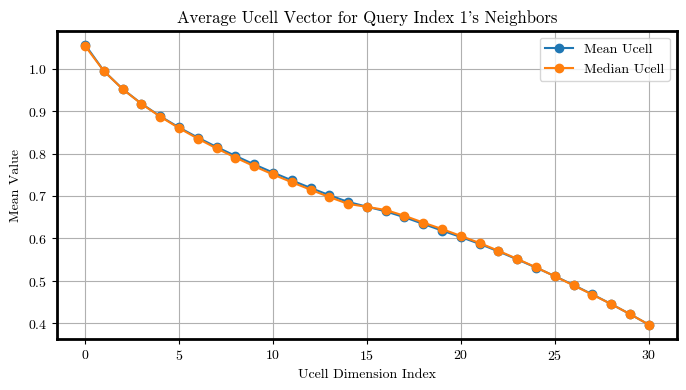

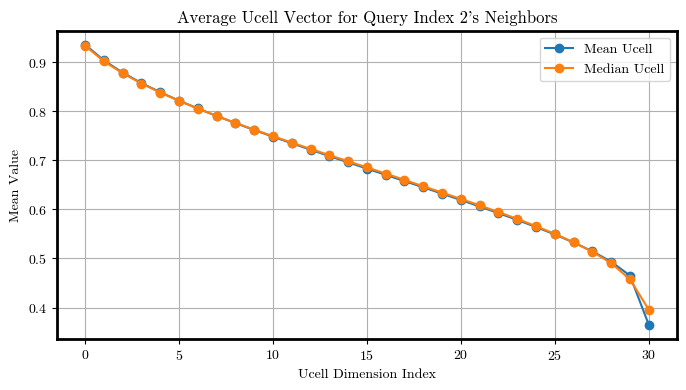

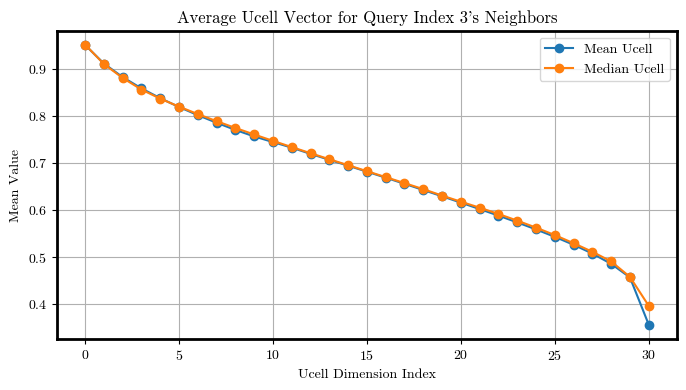

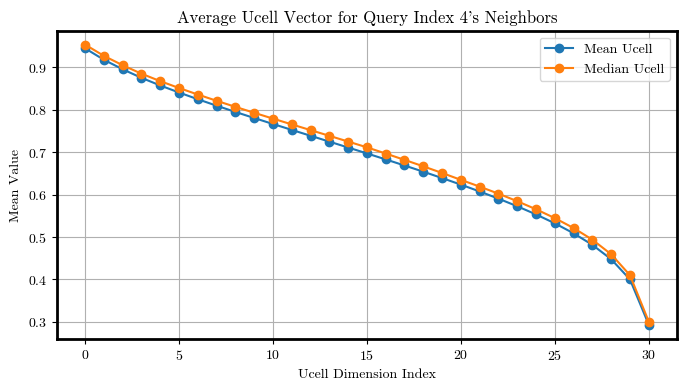

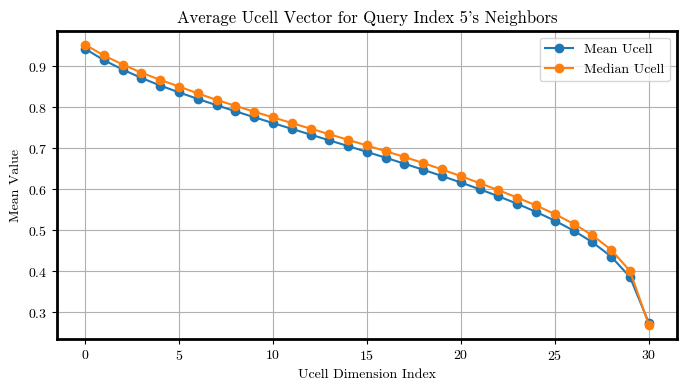

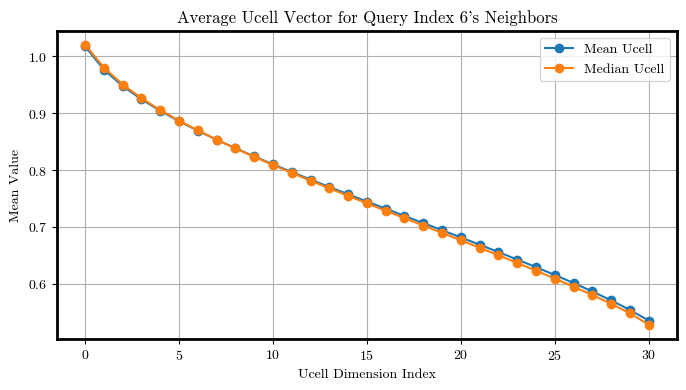

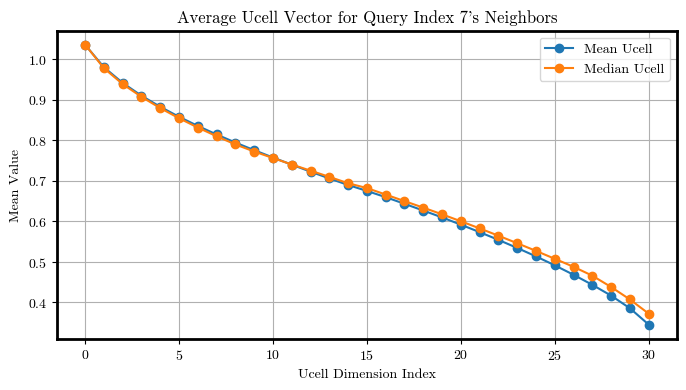

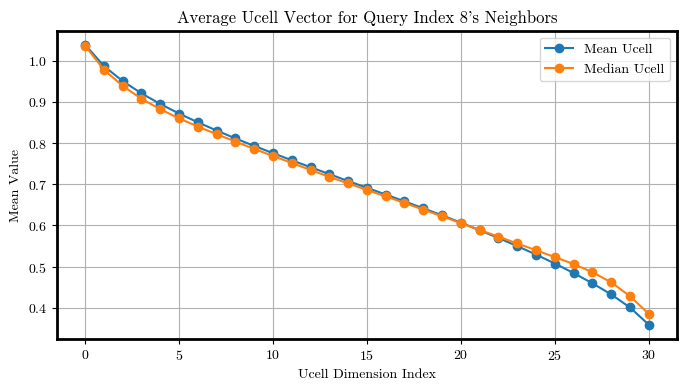

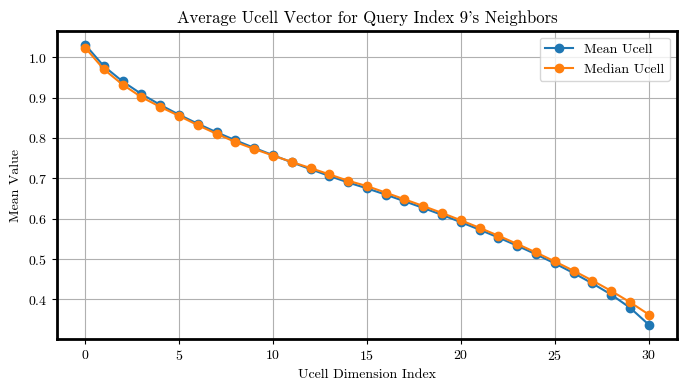

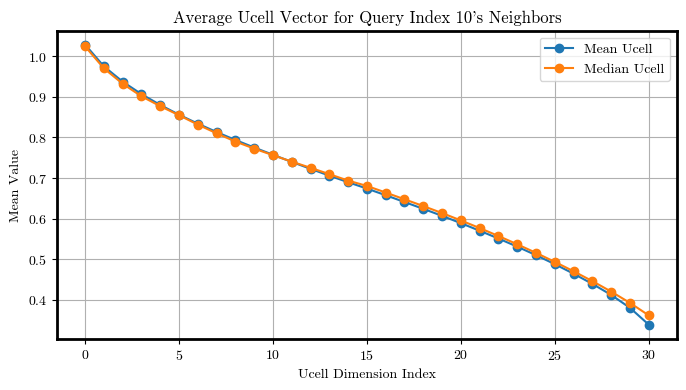

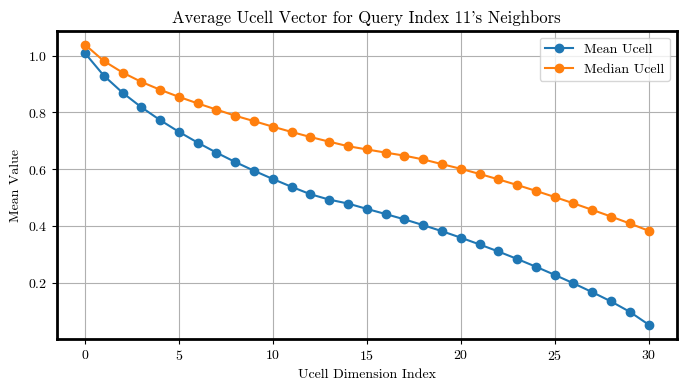

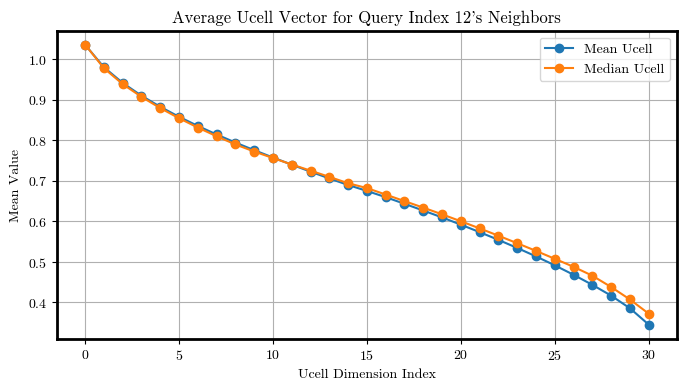

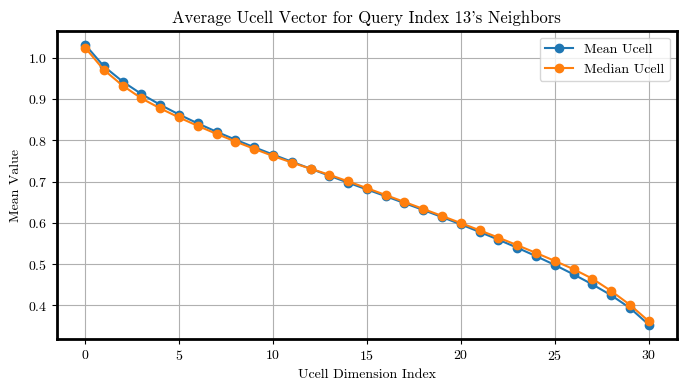

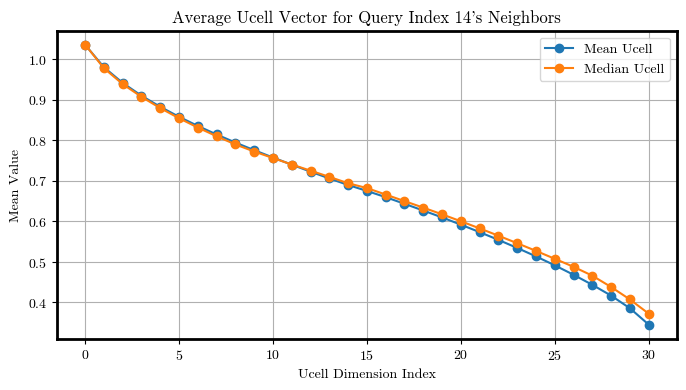

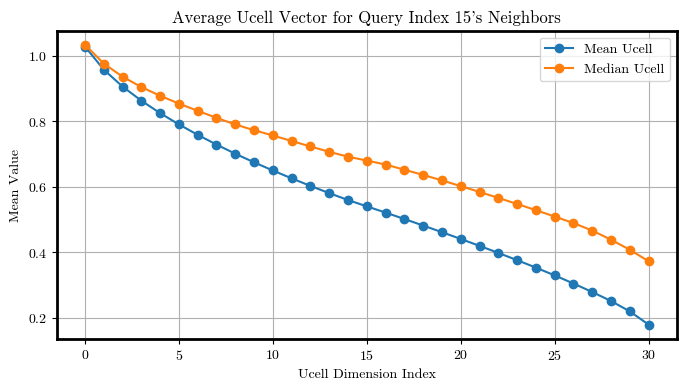

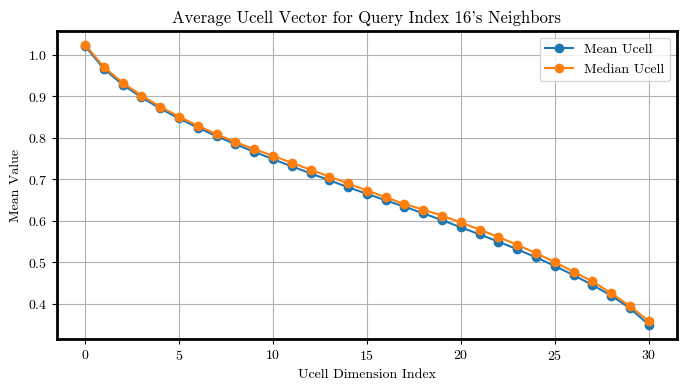

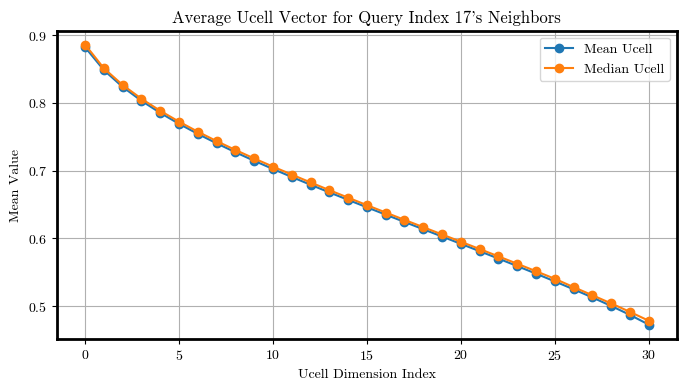

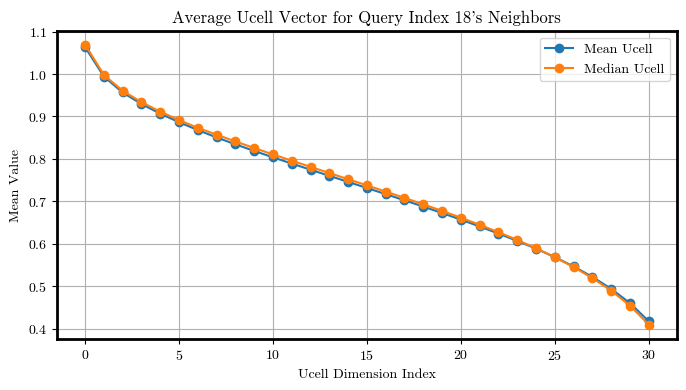

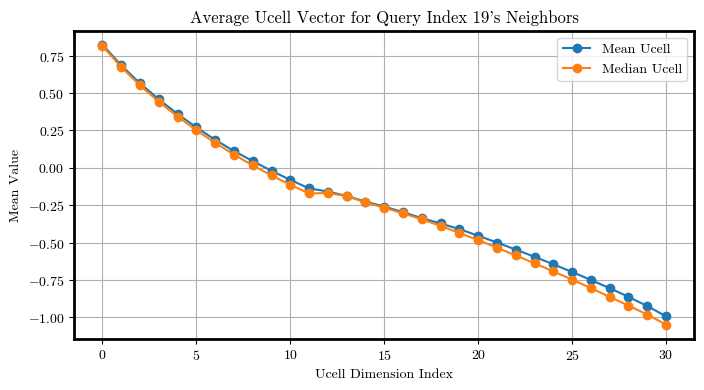

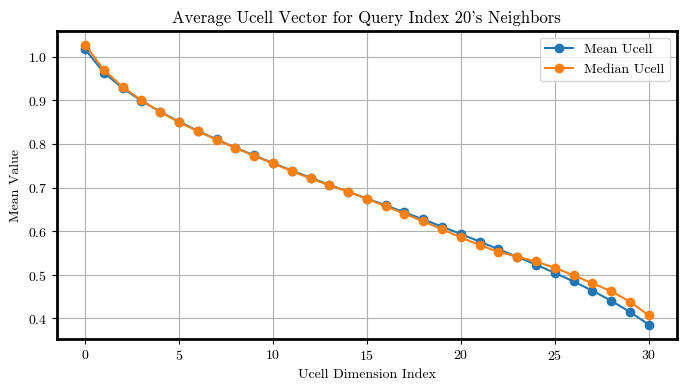

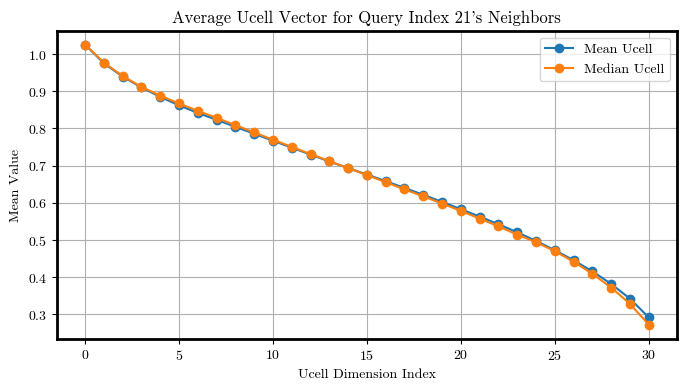

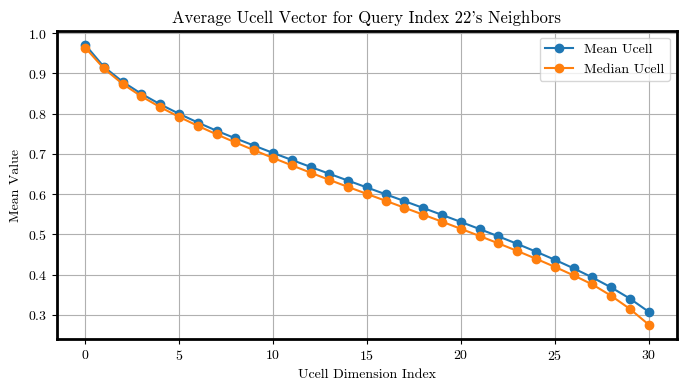

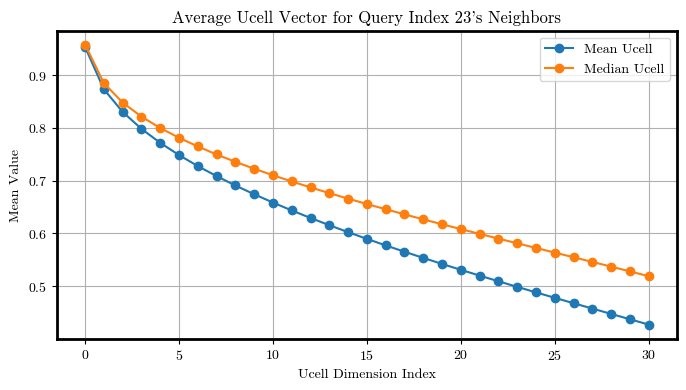

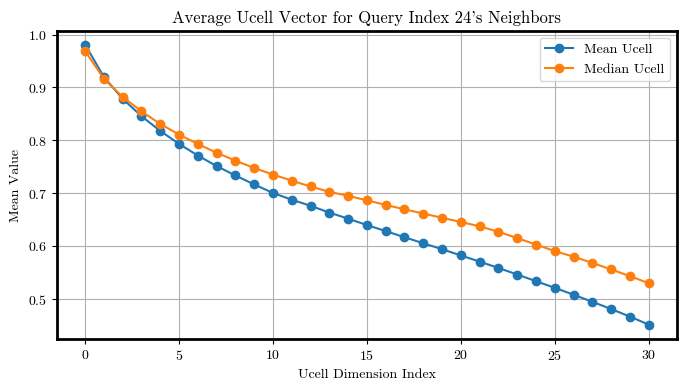

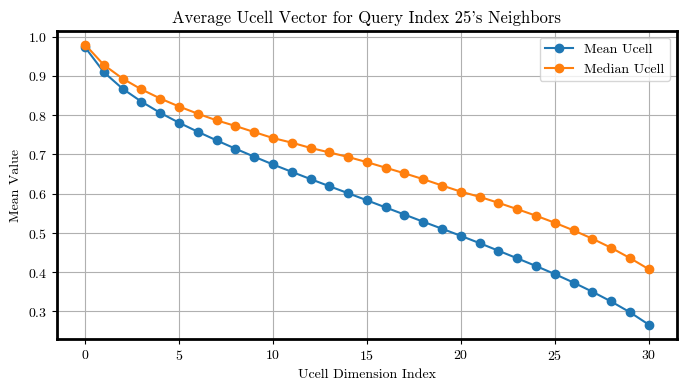

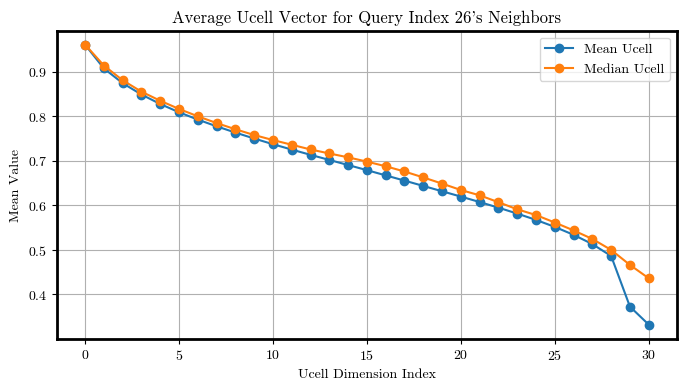

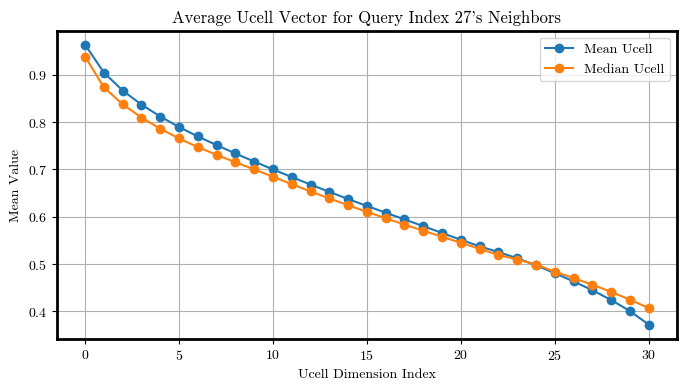

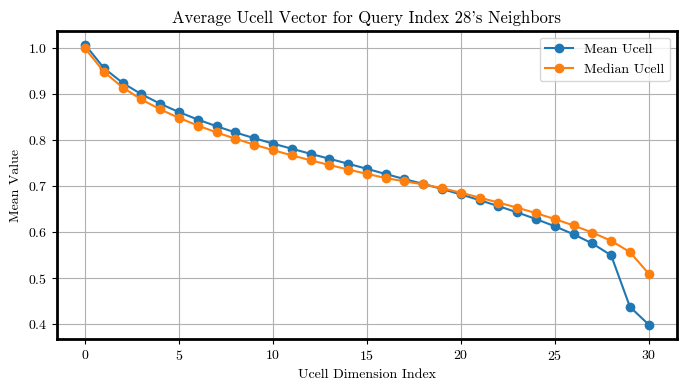

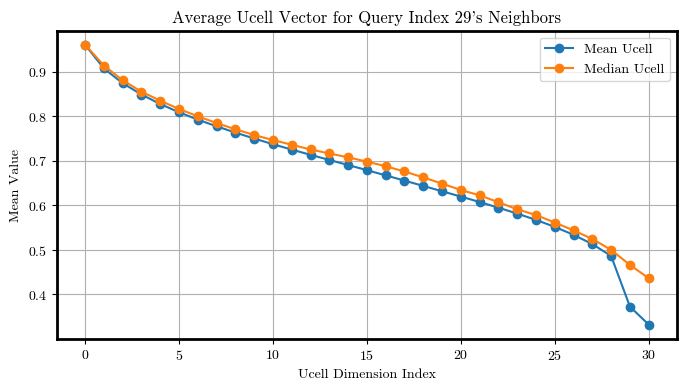

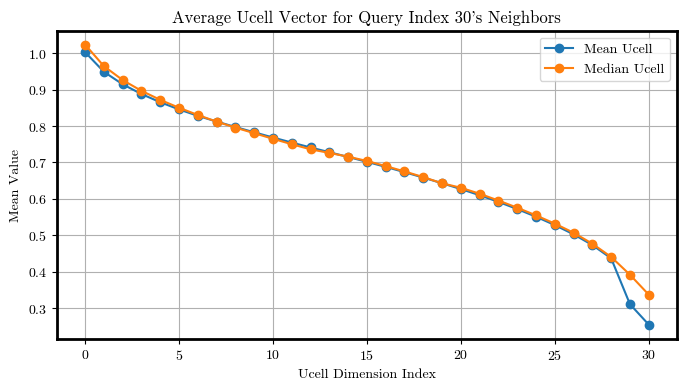

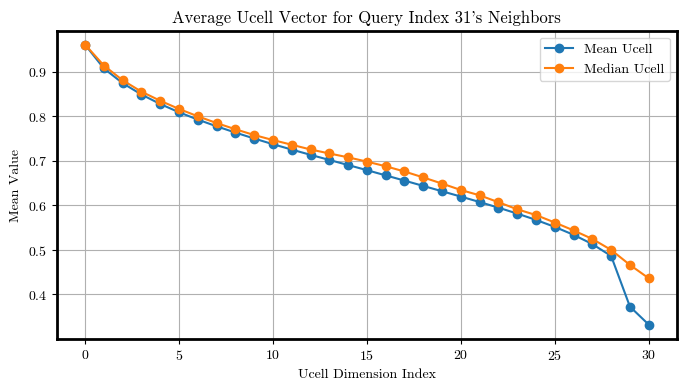

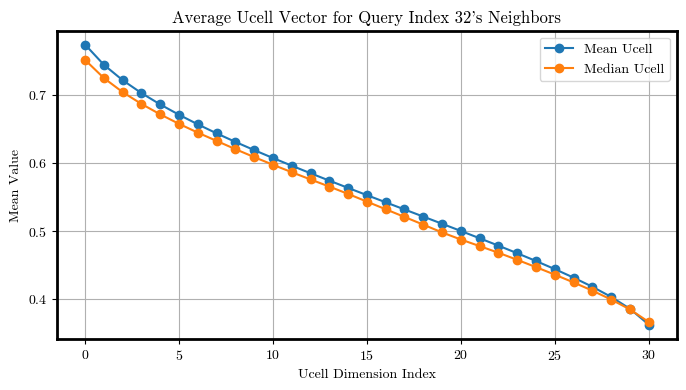

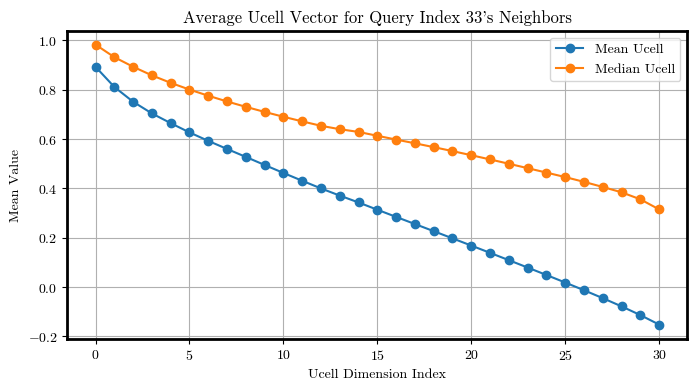

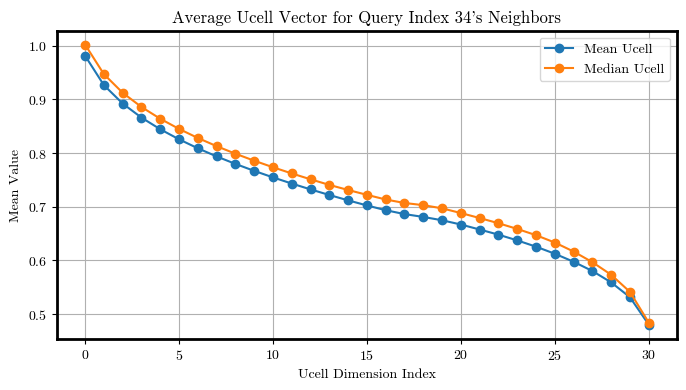

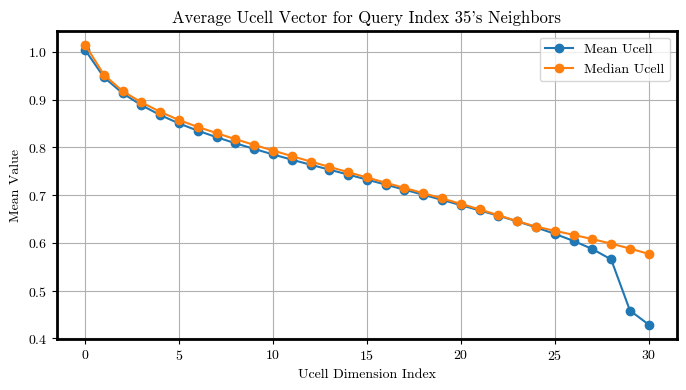

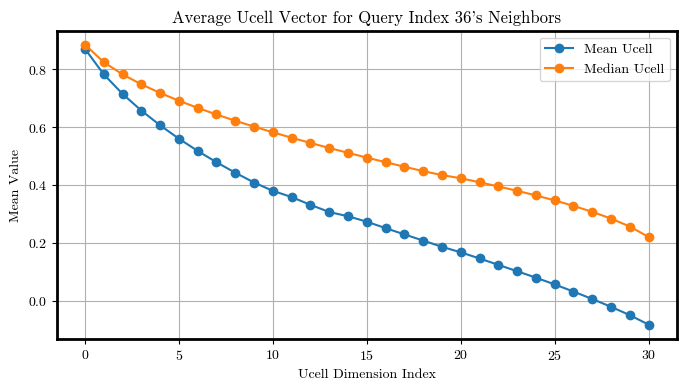

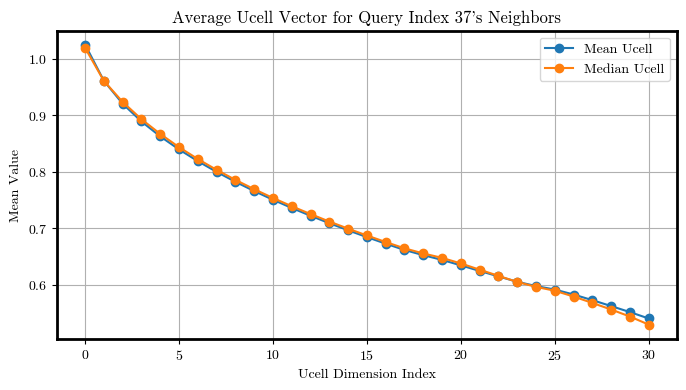

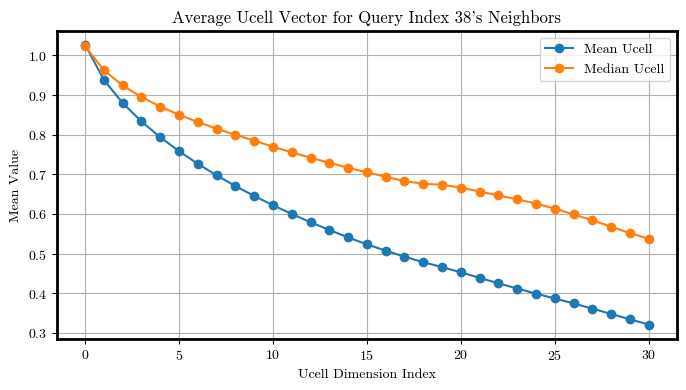

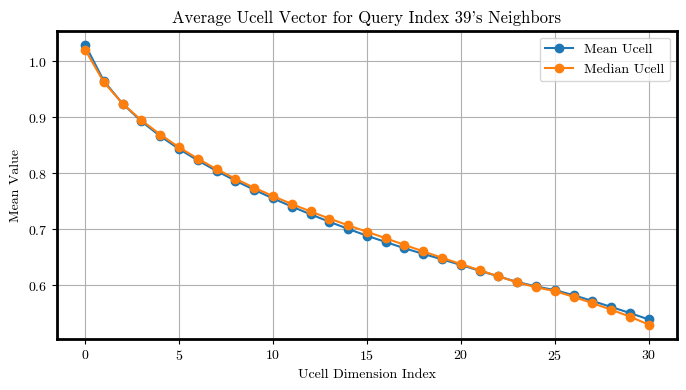

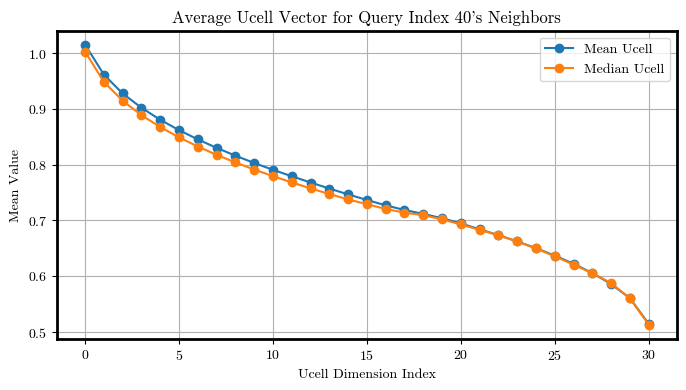

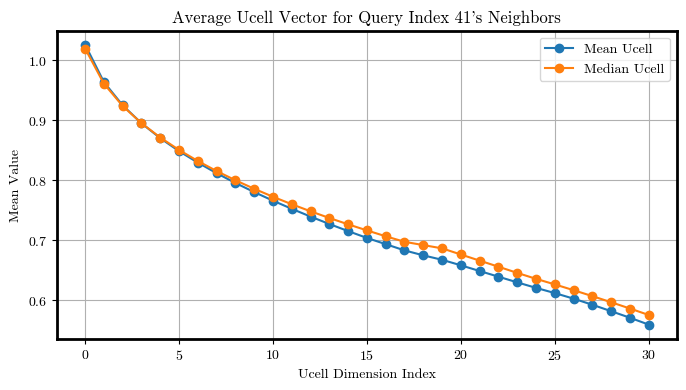

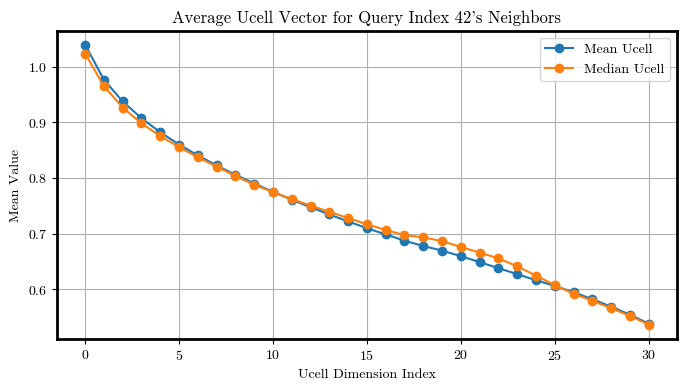

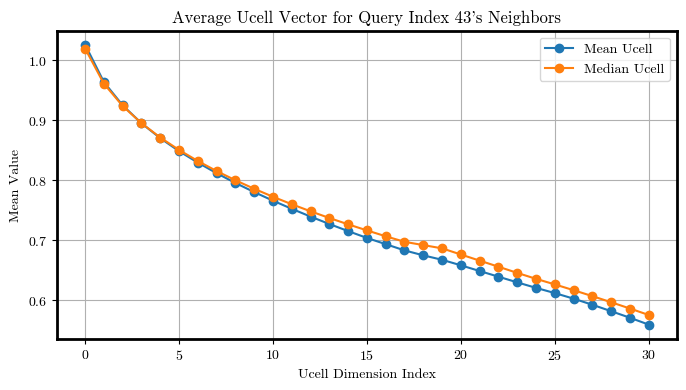

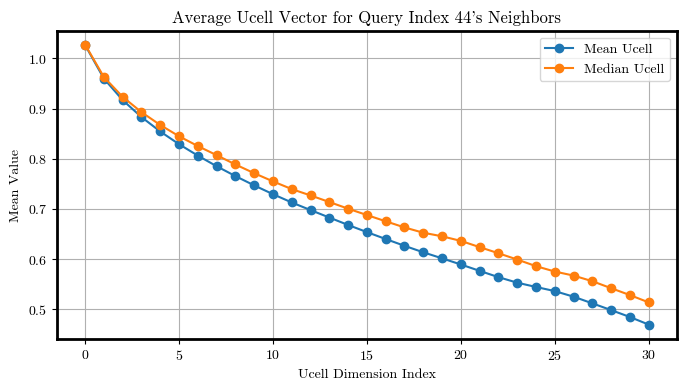

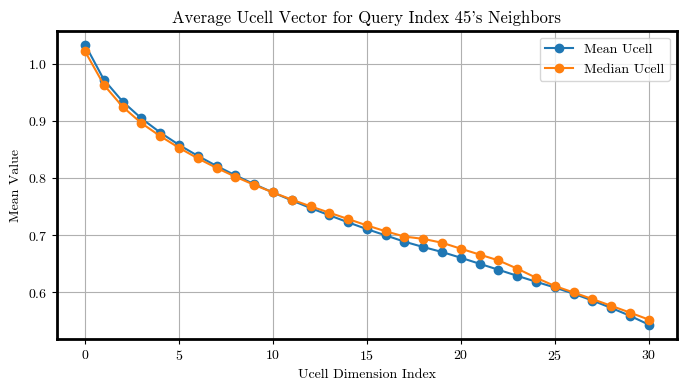

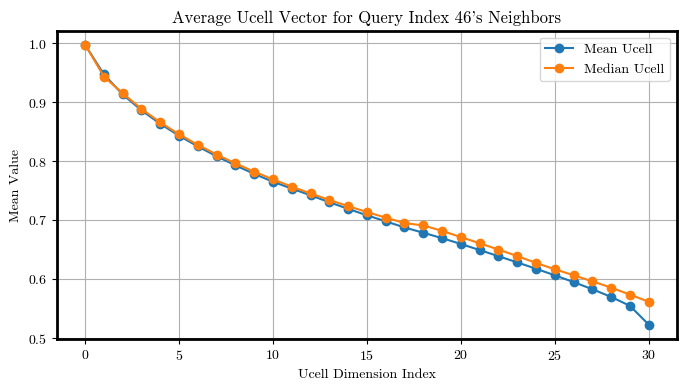

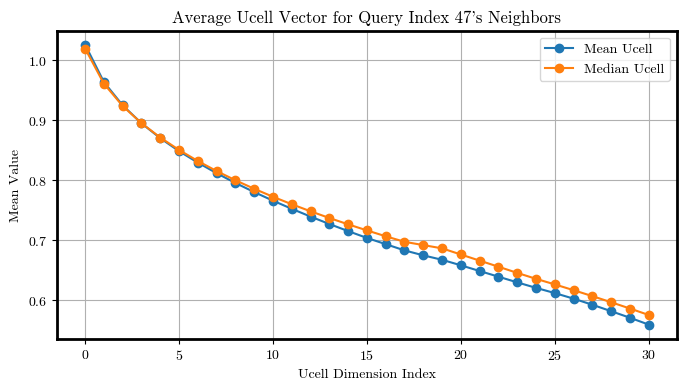

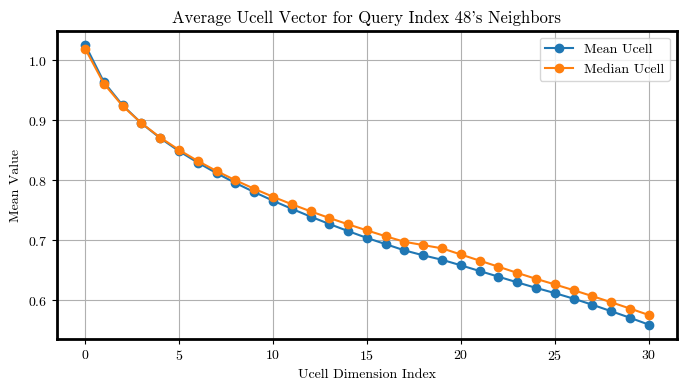

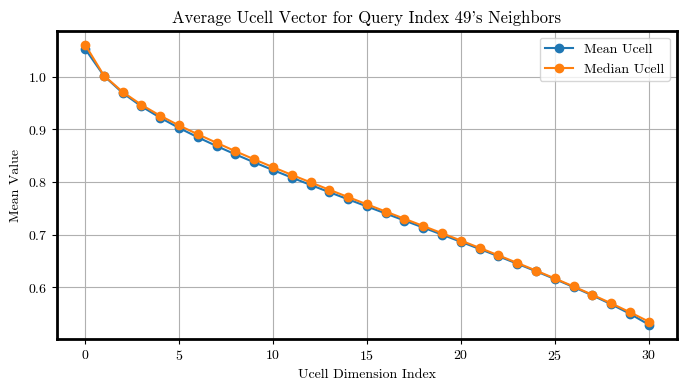

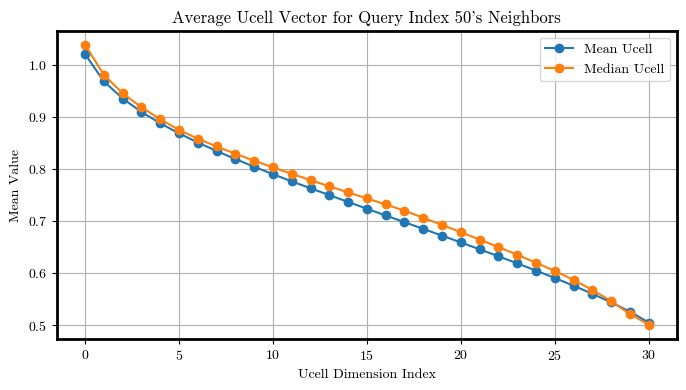

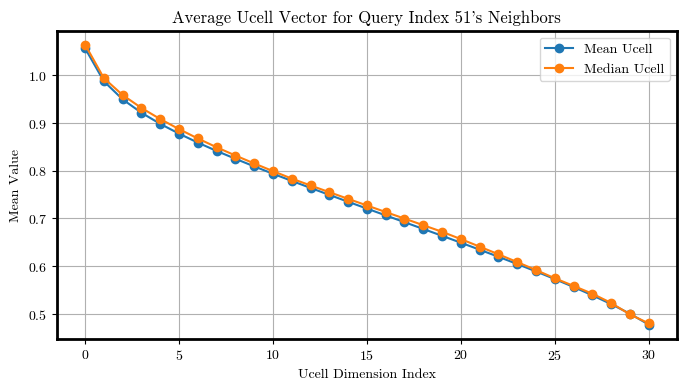

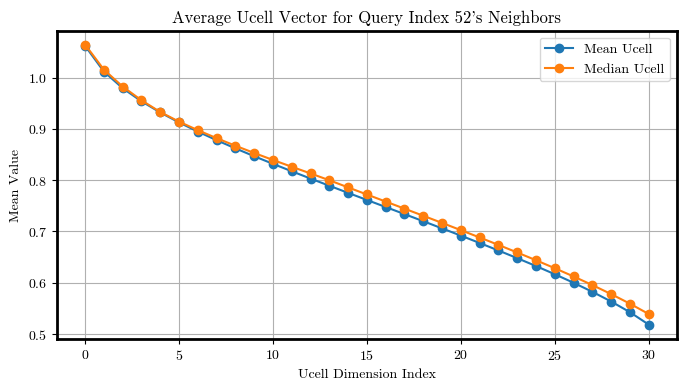

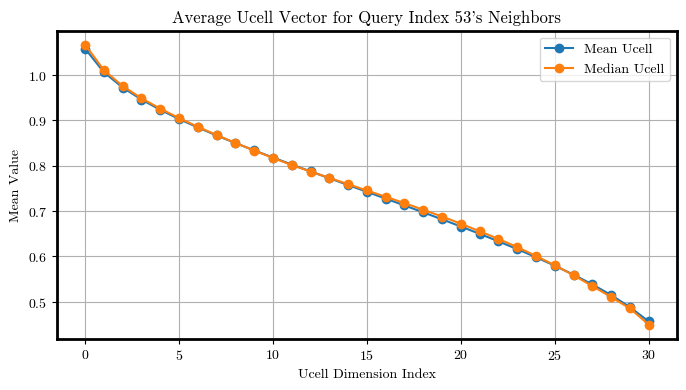

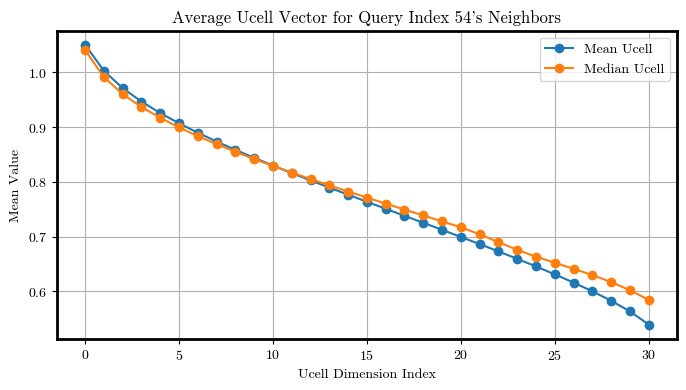

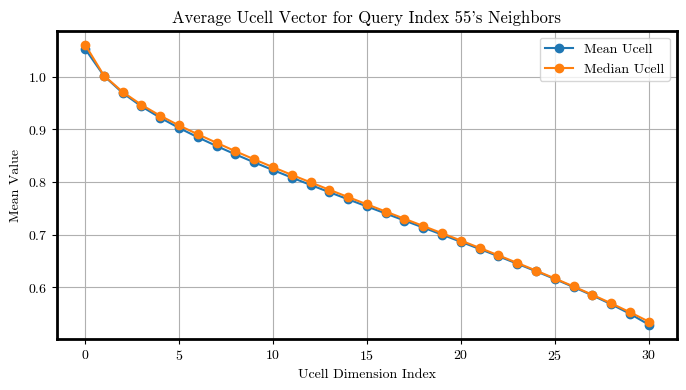

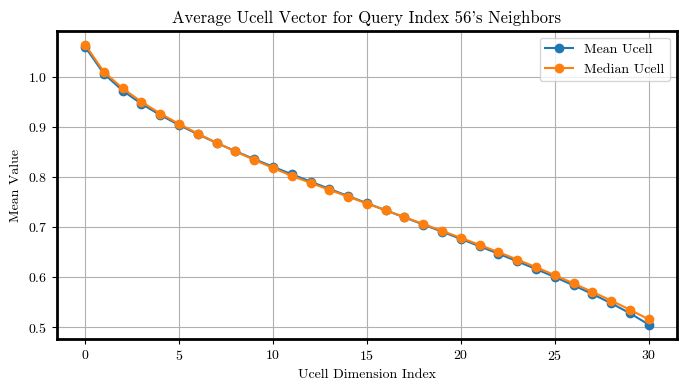

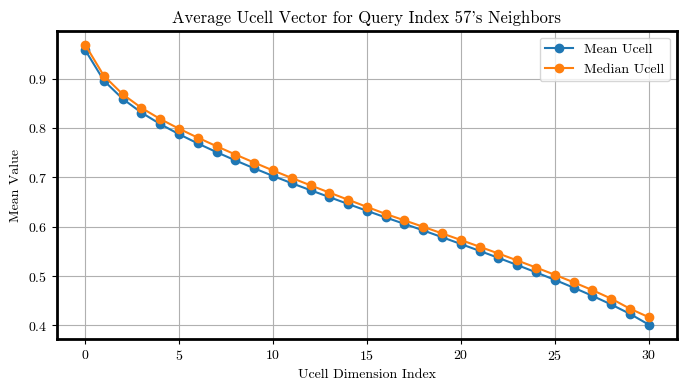

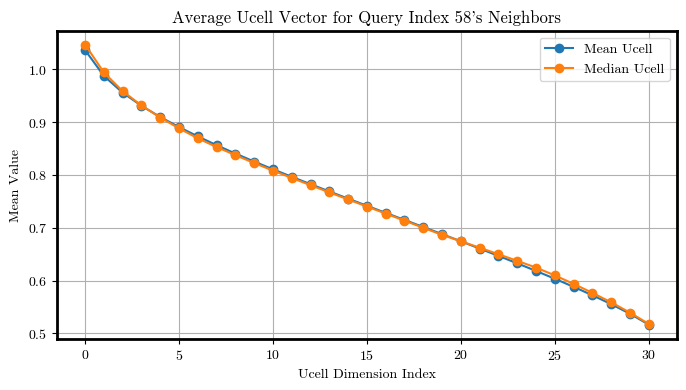

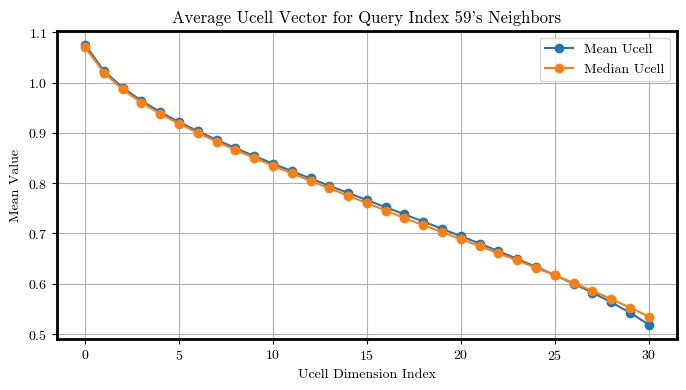

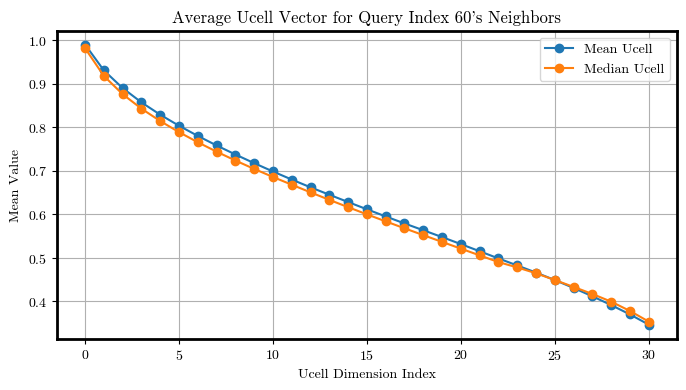

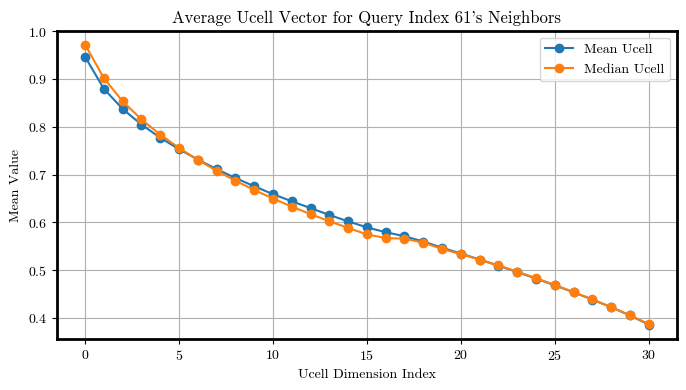

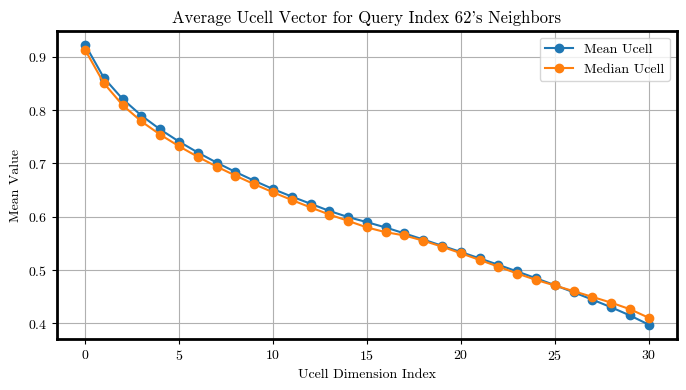

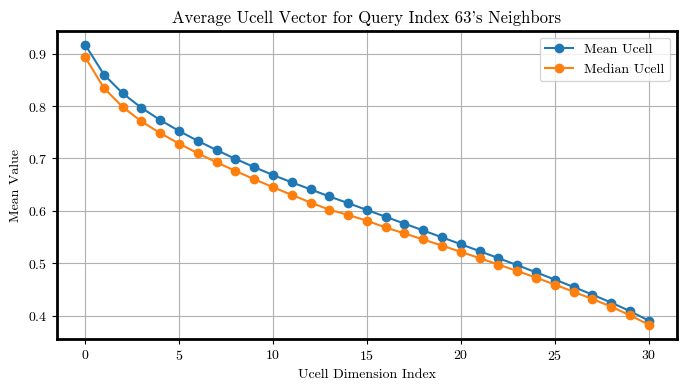

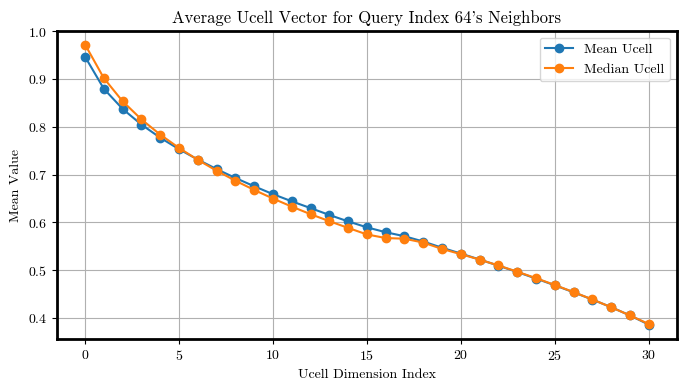

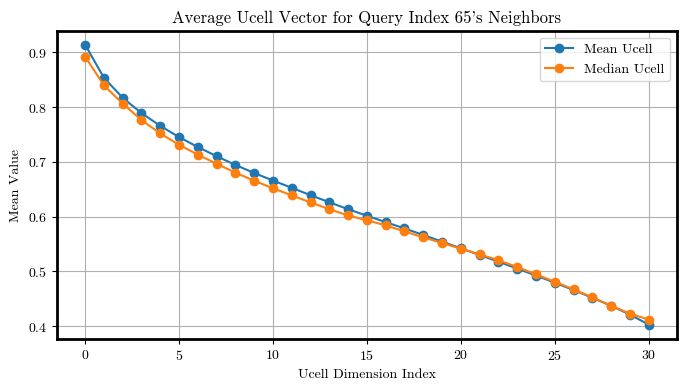

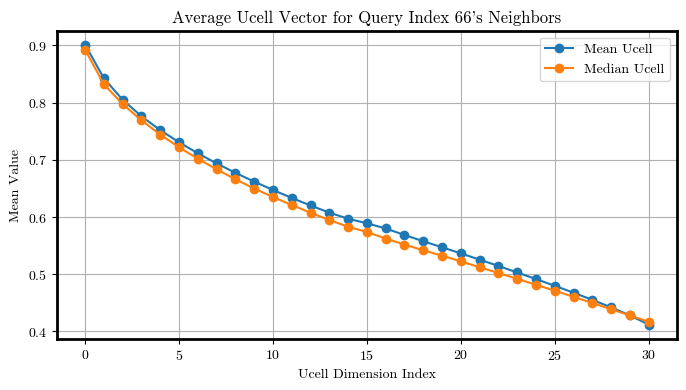

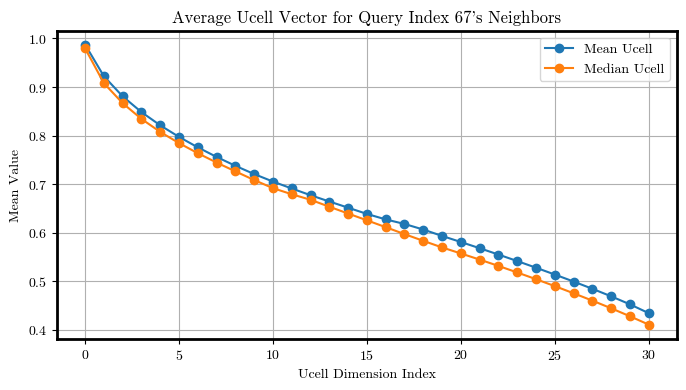

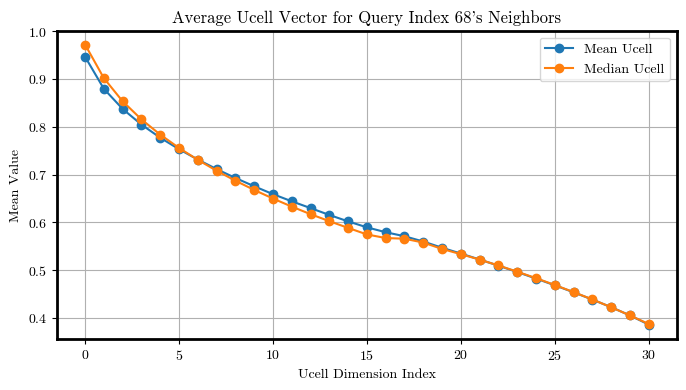

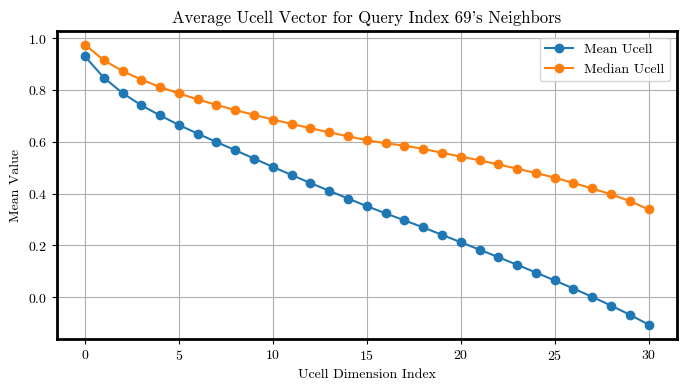

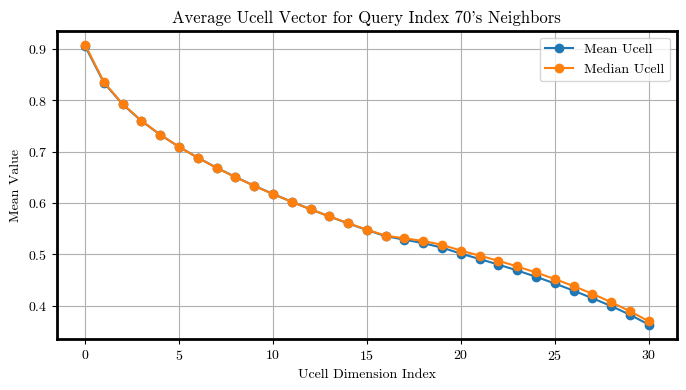

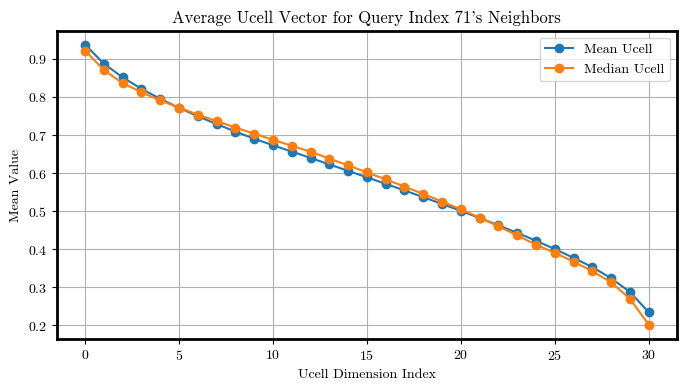

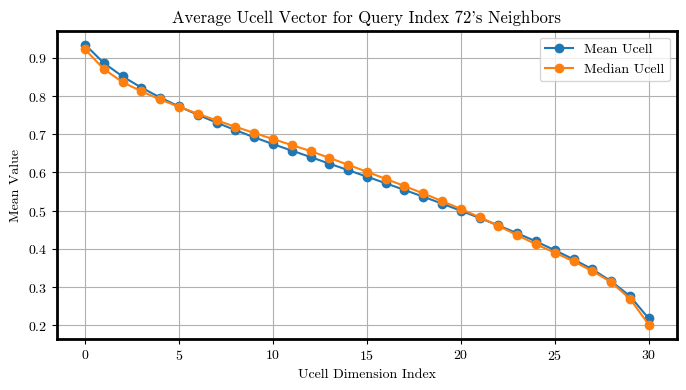

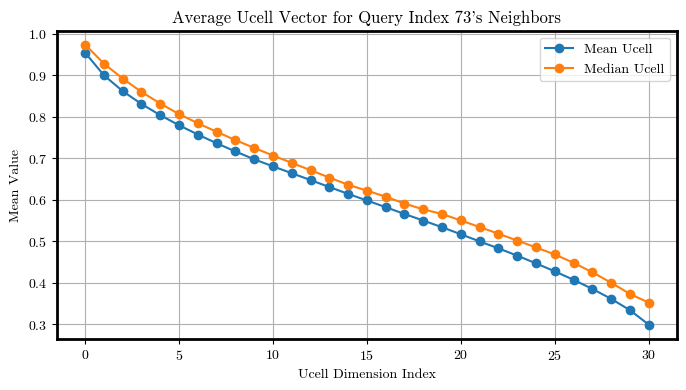

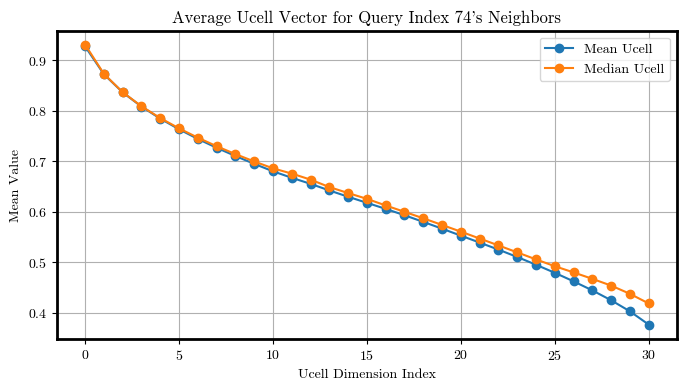

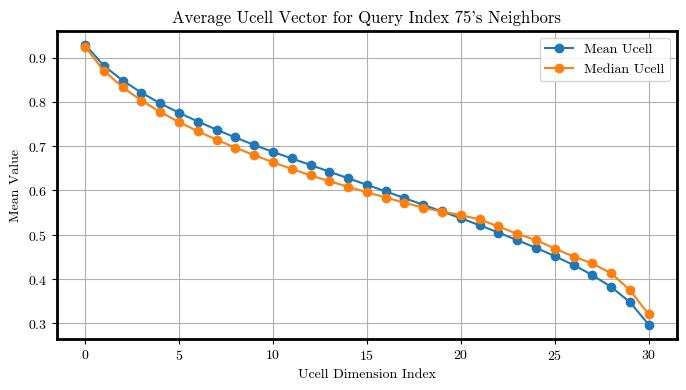

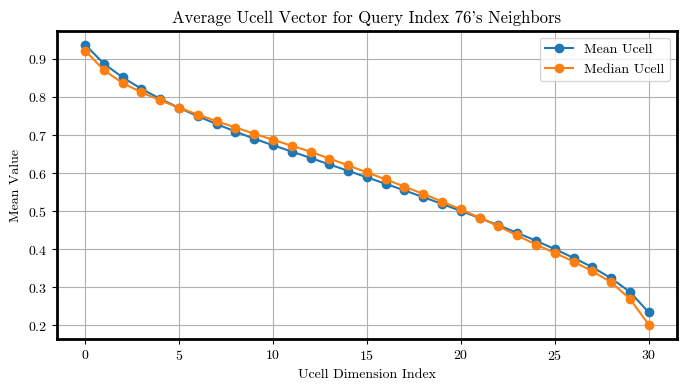

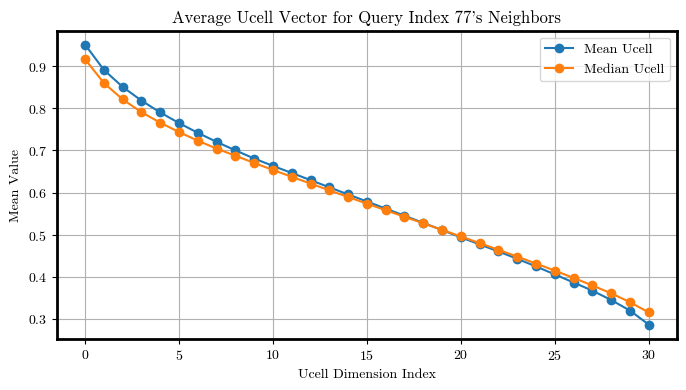

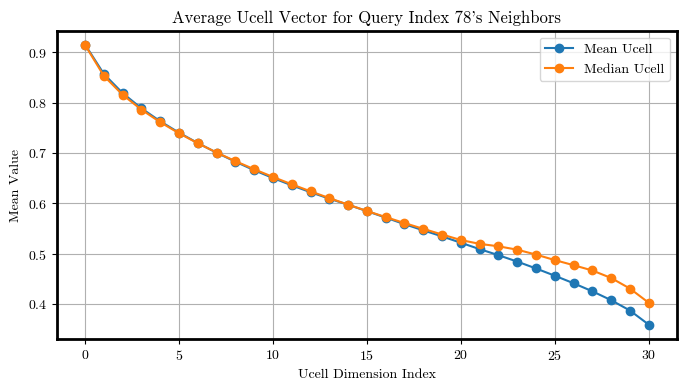

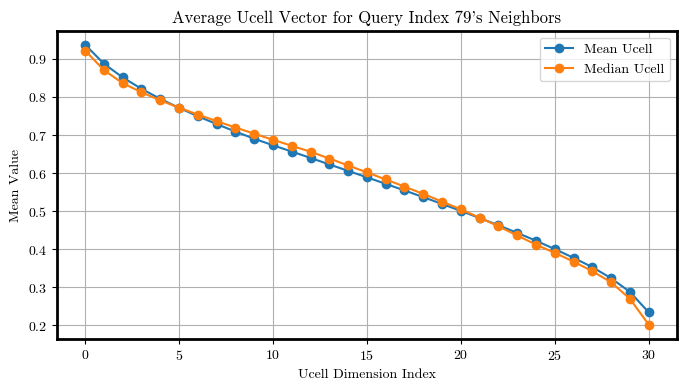

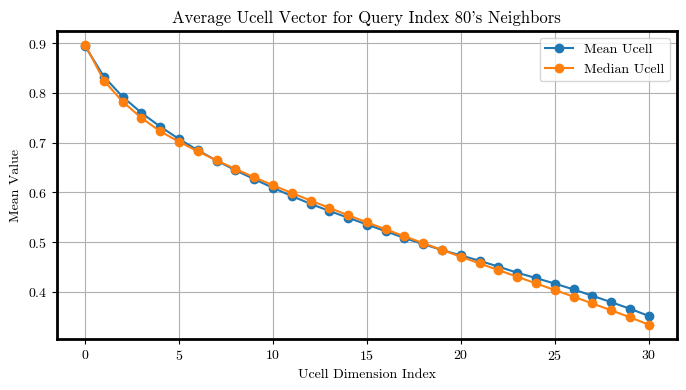

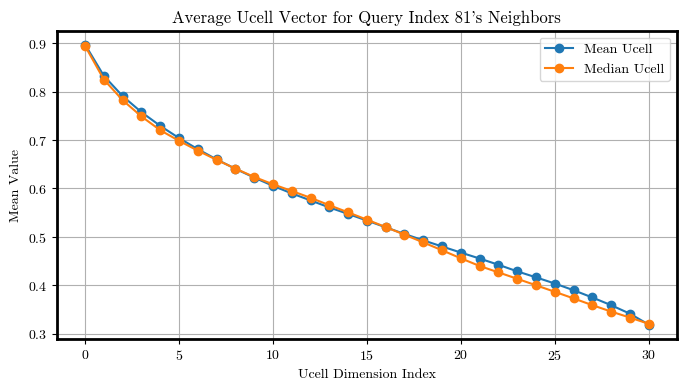

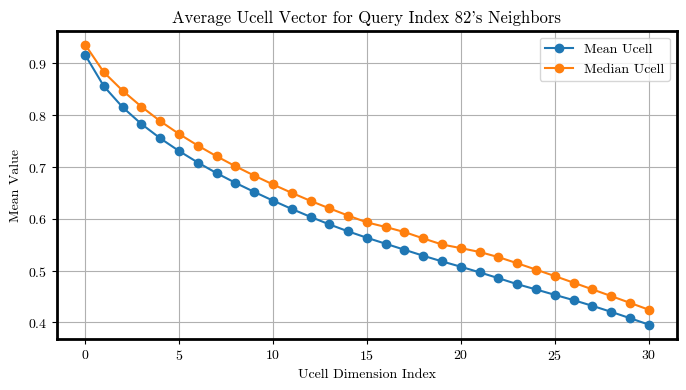

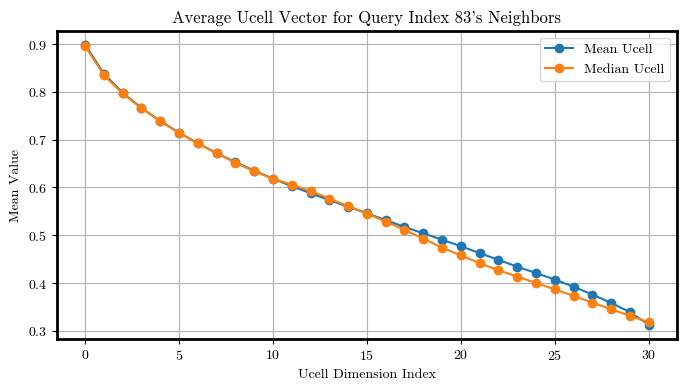

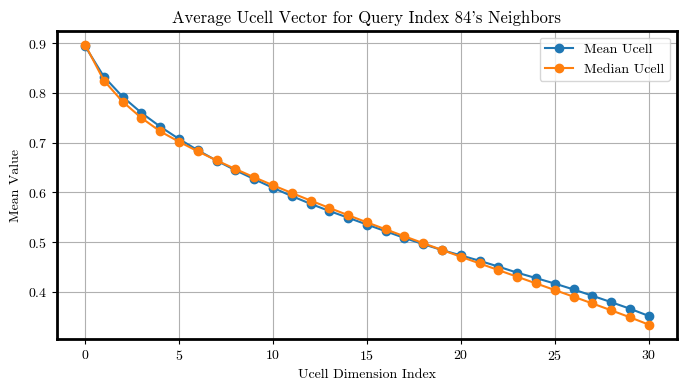

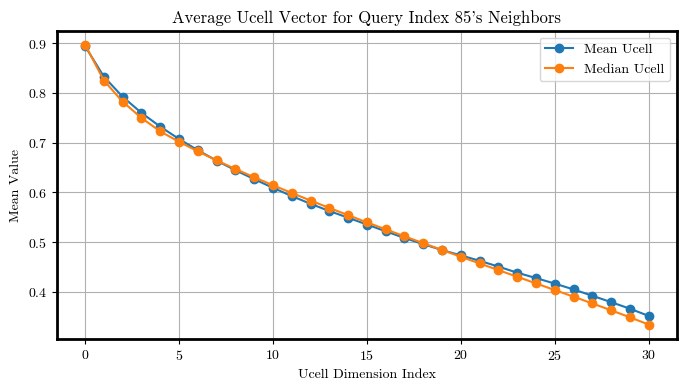

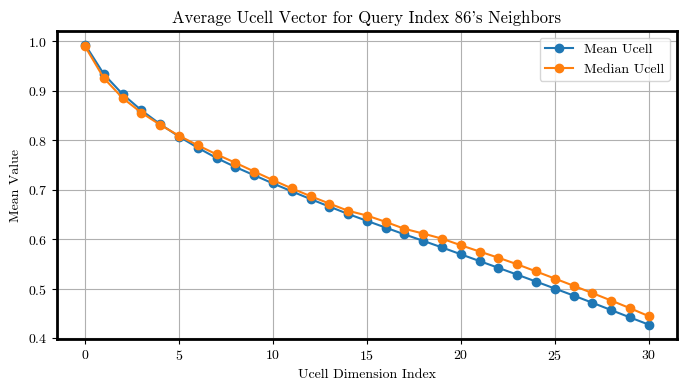

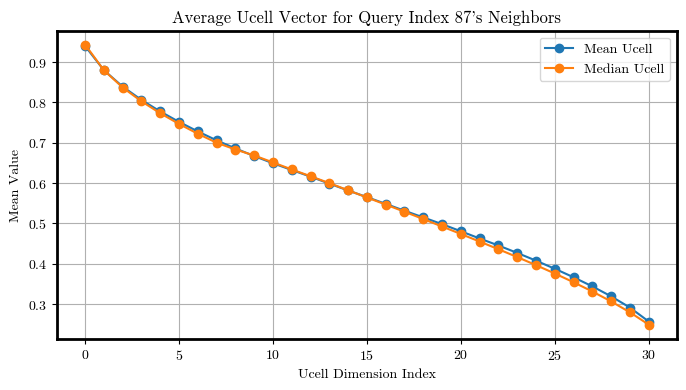

In [14]:
import matplotlib.pyplot as plt
outputs_knn_mean=[]
outputs_knn_median=[]

ifc_outputs_knn_mean=[]
for i, neighbors in enumerate(nearest_indices):
    ifc_mean = np.stack(final_df_valid_cmpl.iloc[neighbors]['ifc']).mean(axis=0)
    ifc_outputs_knn_mean.append(ifc_mean)
    ucell_mean = np.stack(final_df_valid_cmpl.iloc[neighbors]['Ucell']).mean(axis=0)
    ucell_median = np.median(np.stack(final_df_valid_cmpl.iloc[neighbors]['Ucell']), axis=0)
    outputs_knn_mean.append(ucell_mean)
    outputs_knn_median.append(ucell_median)

    # plot 
    plt.figure(figsize=(8, 4))
    plt.plot(ucell_mean, marker='o', linestyle='-')
    plt.plot(ucell_median, marker='o', linestyle='-')
    plt.legend(['Mean Ucell', 'Median Ucell'])
    plt.title(f"Average Ucell Vector for Query Index {i+1}'s Neighbors")
    plt.xlabel("Ucell Dimension Index")
    plt.ylabel("Mean Value")
    plt.grid(True)
    plt.show()

In [15]:
df_mean_missing = pd.DataFrame(np.stack(outputs_knn_mean),columns=[f'Ucell_{i}' for i in range(len(outputs_knn_mean[0]))])
df_median_missing = pd.DataFrame(np.stack(outputs_knn_median),columns=[f'Ucell_{i}' for i in range(len(outputs_knn_median[0]))])

We validate the synthetic curves

In [16]:
from src.validity.validity_criteria import validate_polarization_curves
criteria = {
         "start_in_range": True,
         "early_values_in_range": True,
         "monotonic": False,
         "approx_monotonic":True
     }
validated_df_mean_missing = validate_polarization_curves(
    df_mean_missing,
    apply_criteria=criteria,
    filter_invalid=False,
    keep_temp_cols = False,
    approx_monotonic_threshold=0.05
)

validated_df_median_missing = validate_polarization_curves(
    df_median_missing,
    apply_criteria=criteria,
    filter_invalid=False,
    keep_temp_cols = False,
    approx_monotonic_threshold=0.05
)

print(f'Mean:{validated_df_mean_missing.classification.value_counts()},{validated_df_mean_missing.classification.value_counts(normalize=True)}')
print(f'Median:{validated_df_median_missing.classification.value_counts()},{validated_df_median_missing.classification.value_counts(normalize=True)}')

Mean:classification
valid    87
Name: count, dtype: int64,classification
valid    1.0
Name: proportion, dtype: float64
Median:classification
valid    87
Name: count, dtype: int64,classification
valid    1.0
Name: proportion, dtype: float64


As both cases all curves were valid, we're going to impute the mean

In [17]:
final_df_no_output_cmpl['Ucell'] = outputs_knn_median
final_df_no_output_cmpl['ifc'] = ifc_outputs_knn_mean

C:\Users\Camila Bermudez\AppData\Local\Temp\ipykernel_29152\2144415996.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df_no_output_cmpl['Ucell'] = outputs_knn_median
C:\Users\Camila Bermudez\AppData\Local\Temp\ipykernel_29152\2144415996.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df_no_output_cmpl['ifc'] = ifc_outputs_knn_mean


In [18]:
ifc_df_mean_missing = pd.DataFrame(np.stack(ifc_outputs_knn_mean),columns=[f'ifc_{i}' for i in range(len(outputs_knn_mean[0]))])
repeated_cols = ifc_df_mean_missing.columns.to_list()+ df_mean_missing.columns.to_list()
final_df_no_output_cmpl_T = pd.concat([final_df_no_output_cmpl.drop(columns=repeated_cols).reset_index(drop=True), ifc_df_mean_missing,df_mean_missing], axis=1)
final_df_no_output_cmpl_T.index = final_df_no_output_cmpl.index

**We unify the valid and invalid curves with the ones we imputed**

In [20]:
final_df_others_cmpl = final_df.loc[final_df.classification!="invalid_no_output"]
final_imputed = pd.concat([final_df_others_cmpl,final_df_no_output_cmpl_T],axis=0)
final_imputed = final_imputed.sort_index()

In [21]:
final_imputed.shape

(57344, 113)

In [22]:
pd.DataFrame(final_imputed).to_pickle("../sampling_test/validated_final_df_57344_imputed.pkl")

---------------------------------------------------------------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------------------------------------------------------------

## **3. Section** - Sobol indices calculation

In [ ]:
final_imputed = pd.read_pickle("../sampling_test/validated_final_df_57344_imputed.pkl")

In [ ]:
final_imputed = final_imputed.drop_duplicates(subset='SHA256', keep='first')
final_imputed = final_imputed.reset_index(drop=True)

In [ ]:
final_imputed.shape

(56000, 113)

In [ ]:
parameter_ranges = OmegaConf.load('../param_config.yaml')
dependent_parameter_names = ['Pc_des']
dependent_parameters = [{'parameter_name': 'Pc_des', 'function': lambda Pa_des : Pa_des - 20000, 'dependent_param': 'Pa_des'}]
SA = SensitivityAnalyzer(parameter_ranges, dependent_parameter_names=None, method='sobol', seed=42, N=2048 , calculate_second_order=False)
unscaled = SA.generate_samples()
rescaled = SA.rescale_samples()
id = SA.define_id()
samples = SA.apply_dependent_parameters(dependent_parameters)

In [ ]:
samples.shape

(30720, 15)

In [ ]:
final_imputed['Ucell2'] = final_imputed['Ucell'].apply(lambda x: [i if i >= 0 else 0 for i in x])
#final_imputed['dummy_neg'] = final_imputed['Ucell'].apply(lambda x: np.sum([0 if i >= 0 else 1 for i in x]))
subdata =final_imputed[list(parameter_ranges.keys())+['ifc','Ucell2', 'SHA256']]
subdata.rename(columns={'Ucell2': 'Ucell'}, inplace=True)
print(subdata.shape)
subdata = samples[['SHA256']].merge(subdata,how="left", on='SHA256')
subdata.drop(columns=['SHA256'], inplace=True)
print(subdata.shape)

C:\Users\Camila Bermudez\AppData\Local\Temp\ipykernel_17792\1065945897.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdata.rename(columns={'Ucell2': 'Ucell'}, inplace=True)


(56000, 16)
(30720, 15)


In [ ]:
subdata.head(3)

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c,ifc,Ucell
0,345.931298,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.95271,"[0.0008207962156884239, 0.10081943643864154, 0...","[1.033674925459757, 0.9897215941935267, 0.9578..."
1,350.820492,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.95271,"[0.0008137835137920767, 0.10081241192218332, 0...","[1.0214342244475463, 0.975872411158361, 0.9420..."
2,345.931298,201919.596742,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.95271,"[0.0008164537947848217, 0.10081508672582534, 0...","[1.0367043384089636, 0.9775523869377504, 0.937..."


In [ ]:
def format_output(rankings,Ns):
    rows = []
    for i, feature_dict in enumerate(rankings):
        for feature, values in feature_dict.items():
            row = {
                'id': Ns[i],  # your ID list
                'feature': feature
            }
            # Add region columns dynamically inside the loop
            for region_idx, val in enumerate(values):
                row[f'region_{region_idx}'] = val

            rows.append(row)  # Append inside the inner loop so every feature gets a row

    # Create the DataFrame
    df_rankings = pd.DataFrame(rows)
    return df_rankings


def compute_rankings_for_Ns(parameter_ranges, data, Ns, aggregation_method, by_regions,calculate_second_order=True):
    rankings = []
    indices =[]
    indicess1 =[]
    param_names = None

    for N in Ns:
        SA = SensitivityAnalyzer(
            parameter_ranges,
            dependent_parameter_names=None,
            method='sobol',
            seed=42,
            N=N,
            calculate_second_order=calculate_second_order
        )
        samples = SA.generate_samples()
        subdata = data.iloc[:len(samples)]
        results = SA.run_analysis(subdata, aggregation_method=aggregation_method, by_regions= by_regions)

        # grab ST for output_index 0
        if param_names is None:
            param_names = results[0]['param']

        rank_outputs = []
        indices_outputs =[]
        indices_s1_outputs =[]
        for i in range(len(results)):
            st = next(r['ST'] for r in results if r['output_index'] == i)
            s1 = next(r['S1'] for r in results if r['output_index'] == i)
                        
            order = np.argsort(-st)     # descending
            ranks = np.empty_like(order)
            ranks[order] = np.arange(1, len(st)+1)
            rank_outputs.append(ranks)
            indices_outputs.append(st)
            indices_s1_outputs.append(s1)

        rankings.append(dict(zip(param_names, np.stack(rank_outputs).T)))
        indices.append(dict(zip(param_names, np.stack(indices_outputs).T)))
        indicess1.append(dict(zip(param_names, np.stack(indices_s1_outputs).T)))
    
    df_rankings =  format_output(rankings,Ns)
    df_indices =  format_output(indices,Ns)
    df_indicess1 =  format_output(indicess1,Ns)

 
    return df_rankings,df_indices,df_indicess1


In [ ]:
print(final_imputed.classification.value_counts())
print(final_imputed.classification.value_counts(normalize=True))

classification
valid                54984
invalid                932
invalid_no_output       84
Name: count, dtype: int64
classification
valid                0.981857
invalid              0.016643
invalid_no_output    0.001500
Name: proportion, dtype: float64


In [ ]:
# 1) build the full N list
Ns = list(range(2, 2048, 4))   # [2, 6, 10, …, 254]
#subdata =final_imputed[list(parameter_ranges.keys())+['ifc','Ucell']].iloc[-len(samples):].reset_index(drop=True)
# 2) compute rank_df however you have it
rank_df,indices_df,indices_s1 = compute_rankings_for_Ns(parameter_ranges, subdata, Ns, aggregation_method="AUC",by_regions=True,calculate_second_order=False)

d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))
d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\scipy\stats\_qmc.py:993: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)
d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or

In [ ]:
indices_s1

,id,feature,region_0,region_1,region_2
0,2,Tfc,-1.121818,-1.265647,-0.198622
1,2,Pa_des,-0.830658,-1.083058,-0.024206
2,2,Sc,-0.815114,-0.766893,-0.122812
3,2,Phi_c_des,-0.159334,0.053591,0.022453
4,2,epsilon_gdl,-0.002197,-0.011433,-0.005307
...,...,...,...,...,...
6651,2046,e,0.016570,0.025415,0.023791
6652,2046,Re,-0.019458,0.008637,0.034963
6653,2046,i0_c_ref,0.160110,0.108312,0.105685
6654,2046,kappa_co,-0.009353,0.001263,-0.009032


In [ ]:
import matplotlib.pyplot as plt
# Example Ns list (sample sizes)
def plot_rankings(rank_df,Ns):
    Ns = sorted(rank_df['id'].unique())

    regions = [col for col in rank_df.columns if col.startswith('region_')]

    for region in regions:
        plt.figure(figsize=(10, 6))
        cmap = plt.get_cmap('tab20', len(rank_df['feature'].unique()))

        for idx, feature in enumerate(rank_df['feature'].unique()):
            # Filter rows for the current feature
            feature_data = rank_df[rank_df['feature'] == feature]
            # Sort by sample size id to get consistent order
            feature_data = feature_data.set_index('id').loc[Ns]

            # Get ranking values for current region
            y = feature_data[region]

            plt.plot(Ns, y, color=cmap(idx), label=feature)

        plt.gca().invert_yaxis()
        plt.xticks([2, 32, 64, 96, 128, 256, 512,1024,2048])
        plt.xlabel("Sample size N")
        plt.ylabel("Rank (1 = most important)")
        plt.title(f"Sobol Total-Order Ranking vs. N for {region}")# (Distinct Colors)
        plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize="small", ncol=1)
        plt.tight_layout()
        plt.show()


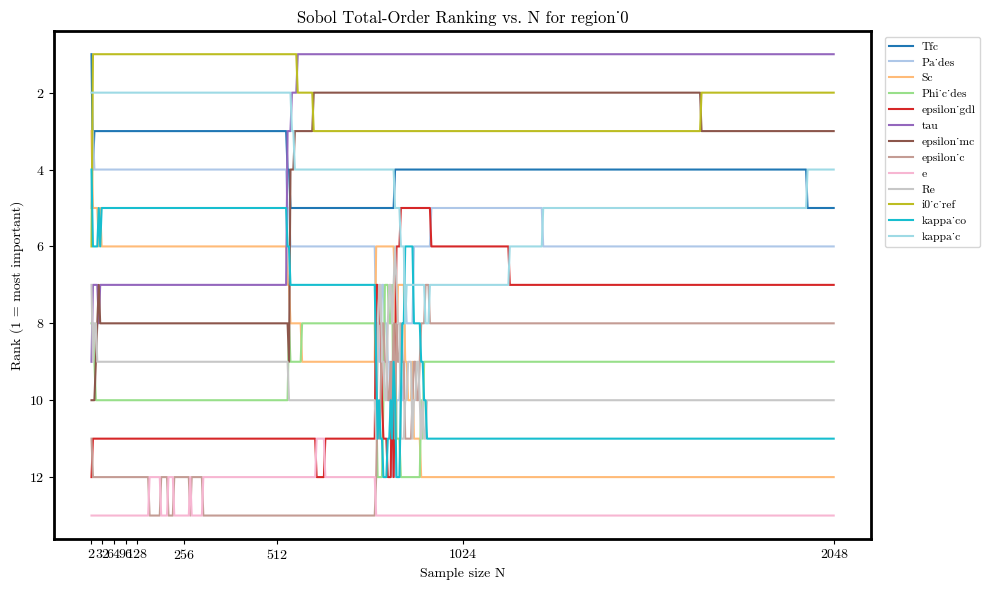

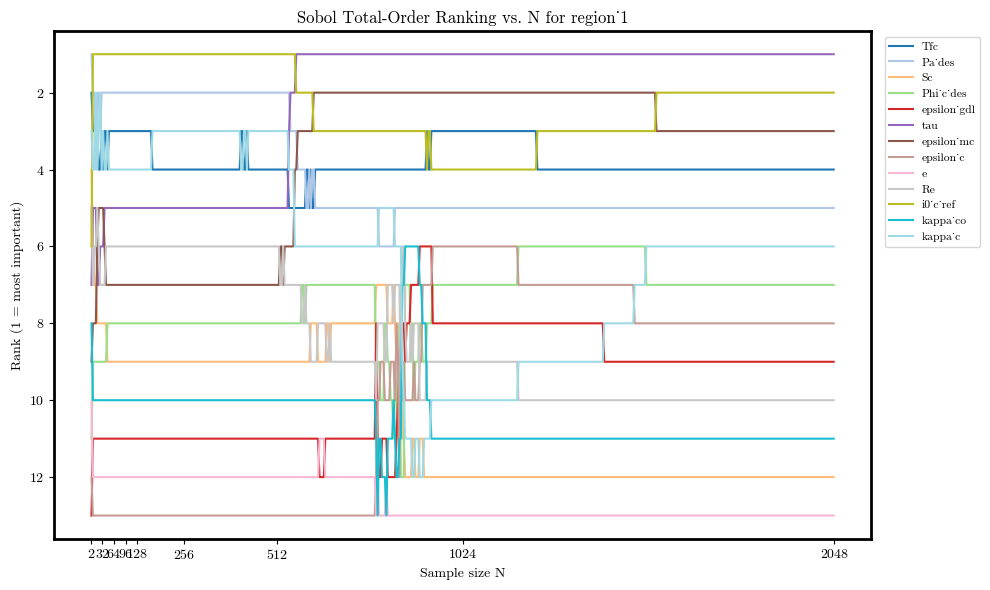

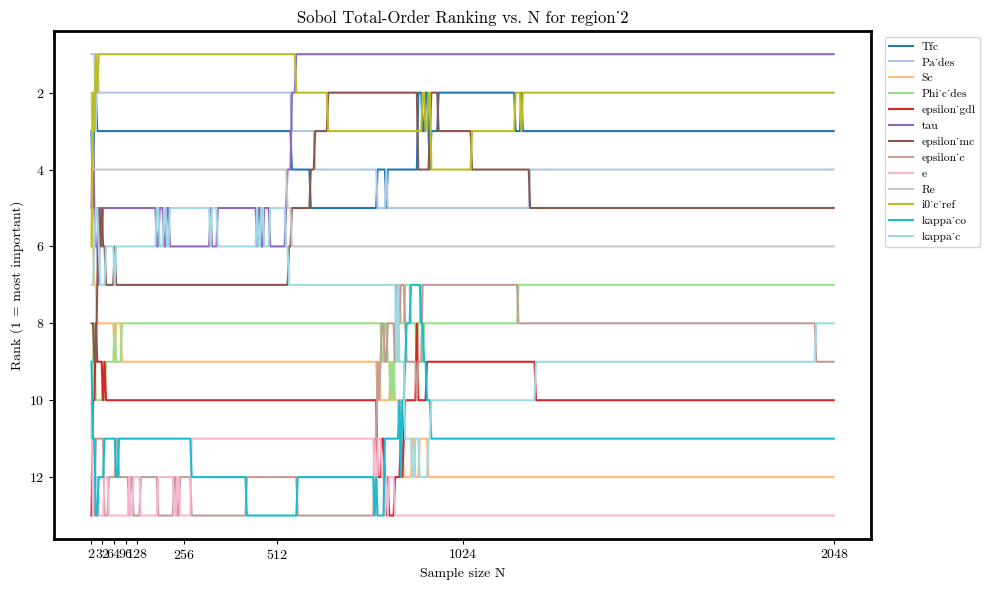

In [ ]:
plot_rankings(rank_df,Ns)

d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))
d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\scipy\stats\_qmc.py:993: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)
d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or

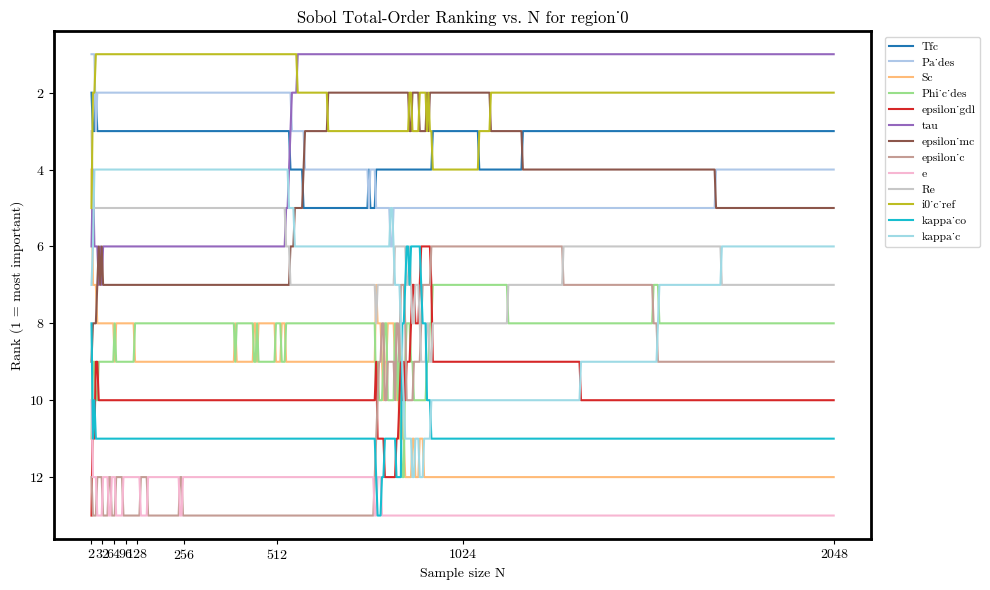

In [ ]:
rank_df_1region,indices_df_1region,indices_s1_df_1region = compute_rankings_for_Ns(parameter_ranges, subdata, Ns, aggregation_method="fPCA",by_regions=False,calculate_second_order=False)
plot_rankings(rank_df_1region,Ns)

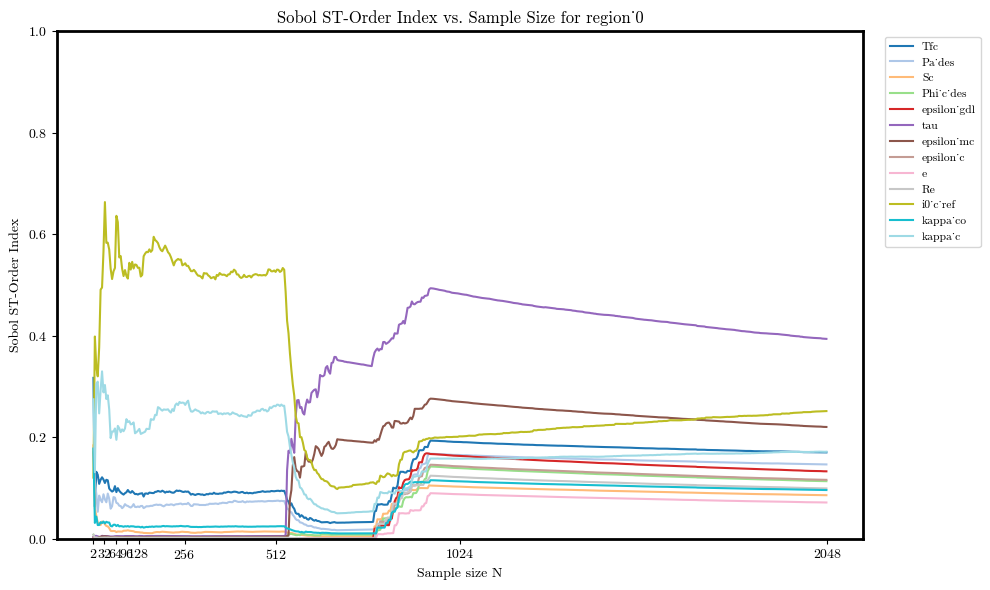

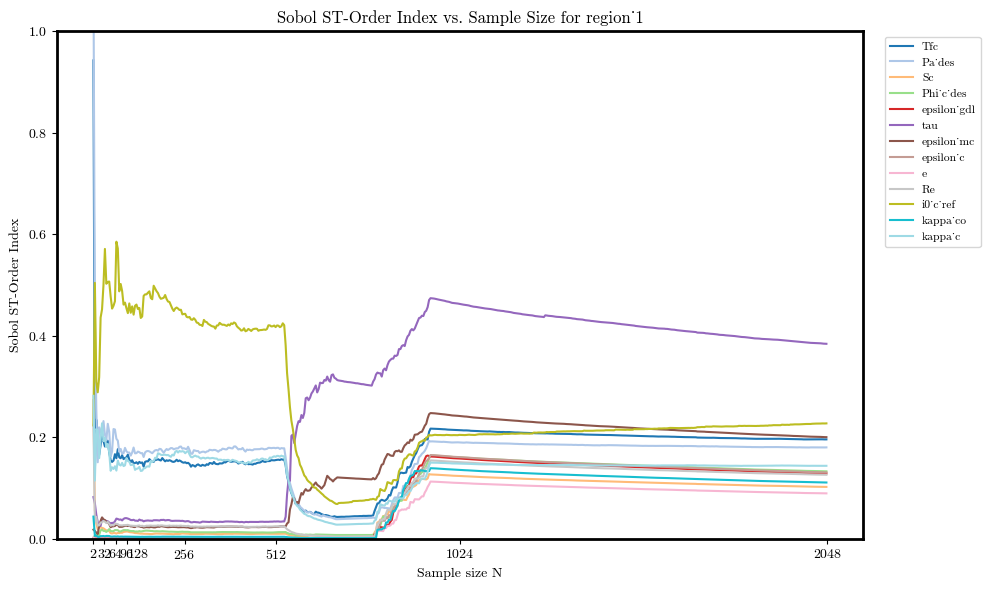

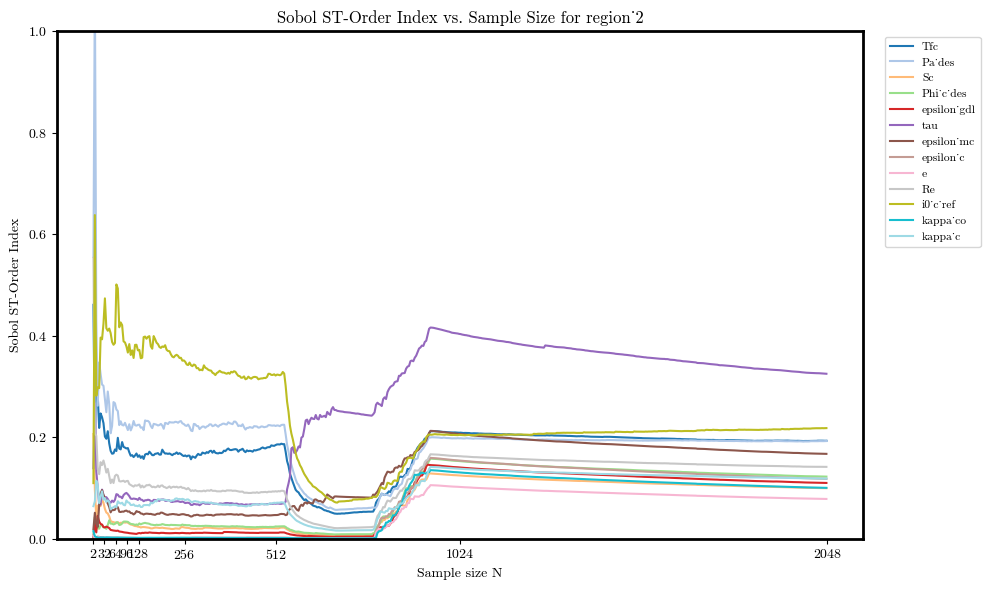

In [ ]:
import matplotlib.pyplot as plt

# Assume rank_df has columns: ['id', 'feature', 'region_0', 'region_1', 'region_2', ...]

def plot_indices(indices_df,type="ST"):
    # Get the list of regions from columns
    regions = [col for col in indices_df.columns if col.startswith('region_')]

    # Sort unique sample sizes in 'id'
    Ns = sorted(indices_df['id'].unique())

    for region in regions:
        plt.figure(figsize=(10, 6))
        features = indices_df['feature'].unique()
        cmap = plt.get_cmap('tab20', len(features))

        for idx, feature in enumerate(features):
            # Select rows for this feature and sort by sample size
            df_feature = indices_df[indices_df['feature'] == feature].set_index('id').loc[Ns]

            # y values are Sobol indices/ranks for this feature in the current region
            y = df_feature[region]

            plt.plot(Ns, y, label=feature, color=cmap(idx))

        plt.xlabel("Sample size N")
        plt.ylabel(f"Sobol {type}-Order Index")
        plt.title(f"Sobol {type}-Order Index vs. Sample Size for {region}")
        plt.xticks([2, 32, 64, 96, 128, 256, 512,1024,2048])
        plt.ylim(0, 1)
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize="small")
        plt.tight_layout()
        plt.show()
plot_indices(indices_df= indices_df,type="ST")

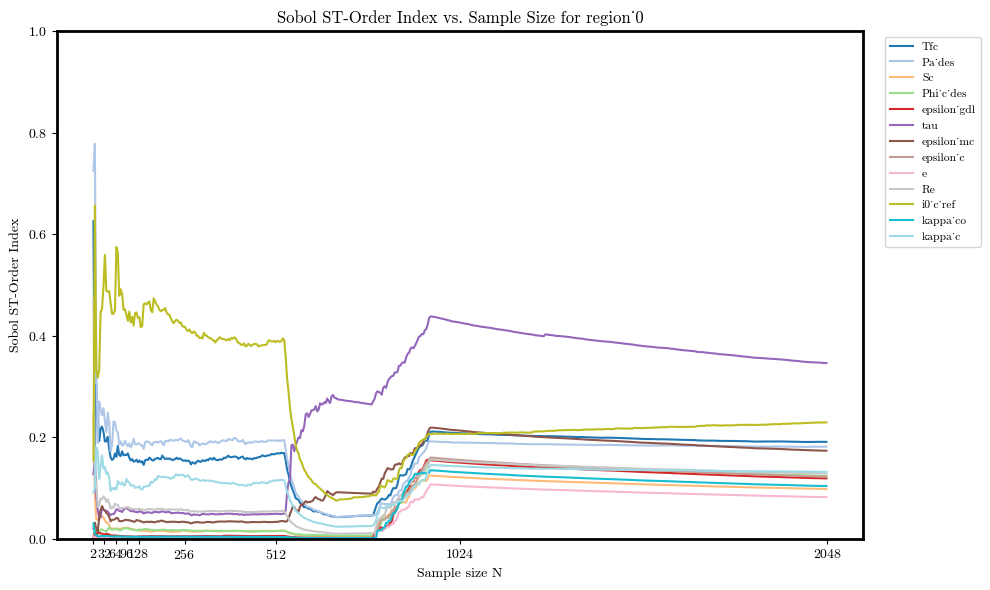

In [ ]:
plot_indices(indices_df= indices_df_1region,type="ST")

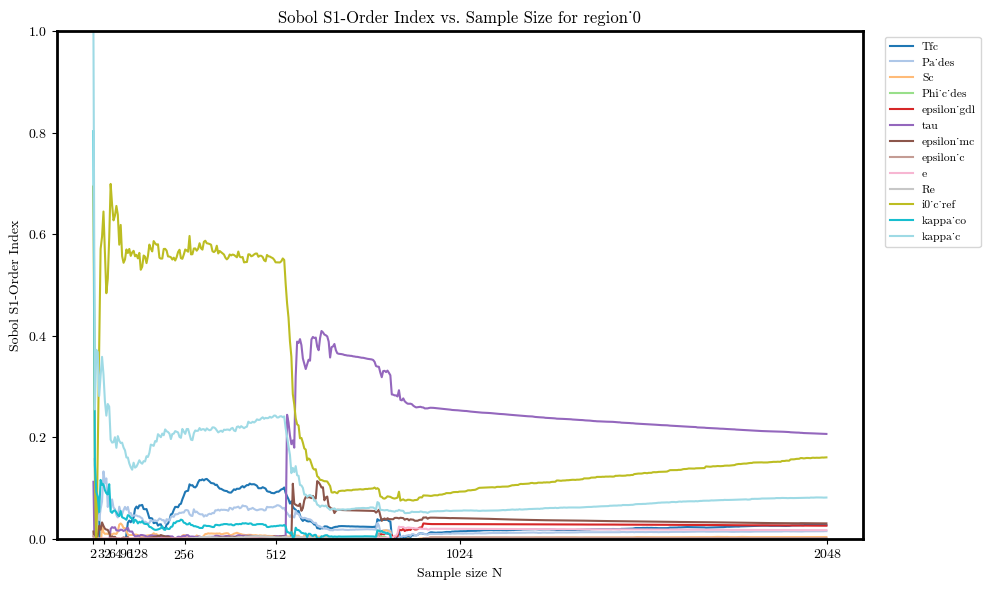

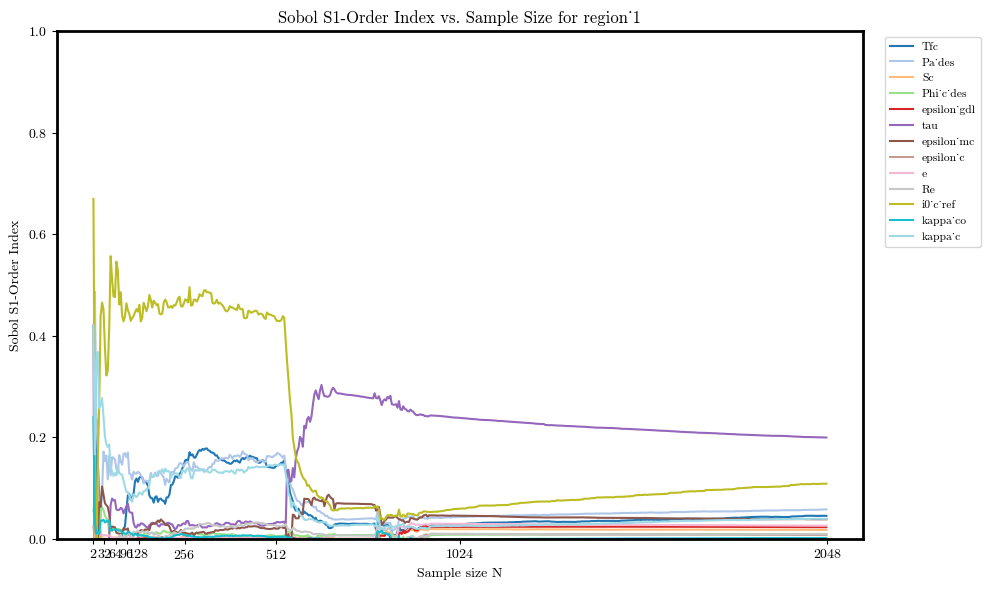

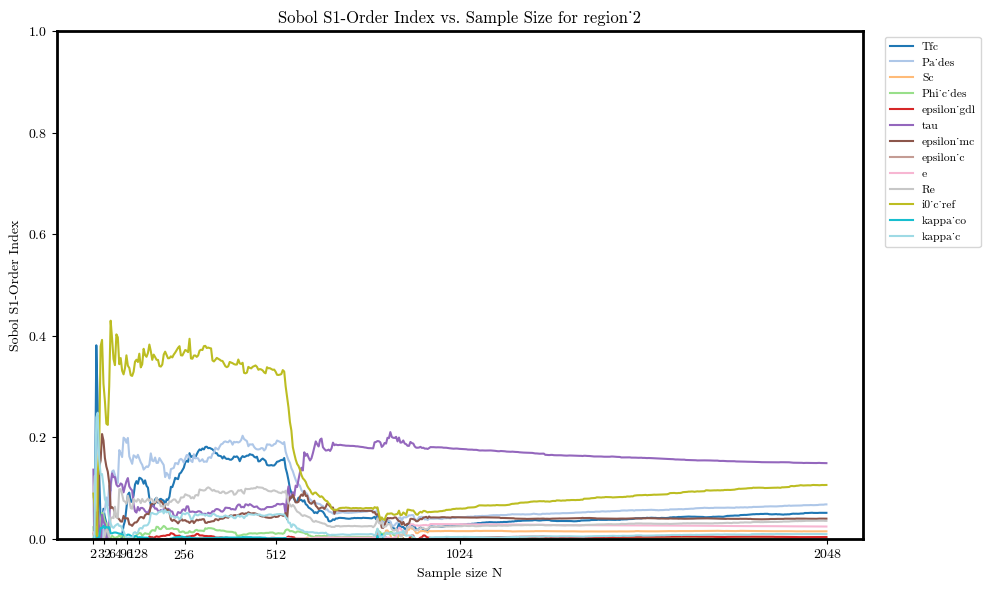

In [ ]:
plot_indices(indices_df= indices_s1,type="S1")

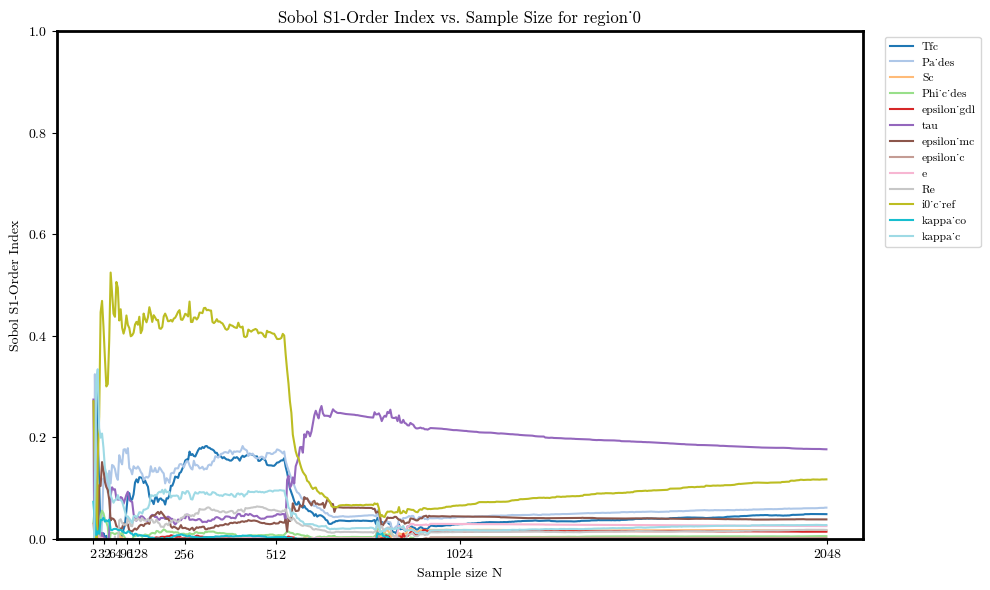

In [ ]:
plot_indices(indices_df= indices_s1_df_1region,type="S1")

In [ ]:
indices_s1.groupby('id').sum()

,feature,region_0,region_1,region_2
id,,,,
2,TfcPa_desScPhi_c_desepsilon_gdltauepsilon_mcep...,-0.441162,-1.820695,-0.229683
6,TfcPa_desScPhi_c_desepsilon_gdltauepsilon_mcep...,0.111059,0.225488,0.085931
10,TfcPa_desScPhi_c_desepsilon_gdltauepsilon_mcep...,0.275166,0.359377,0.164584
14,TfcPa_desScPhi_c_desepsilon_gdltauepsilon_mcep...,0.600275,0.708714,0.361862
18,TfcPa_desScPhi_c_desepsilon_gdltauepsilon_mcep...,0.683039,0.531750,0.242722
...,...,...,...,...
2030,TfcPa_desScPhi_c_desepsilon_gdltauepsilon_mcep...,0.535694,0.578207,0.484482
2034,TfcPa_desScPhi_c_desepsilon_gdltauepsilon_mcep...,0.535548,0.578254,0.484701
2038,TfcPa_desScPhi_c_desepsilon_gdltauepsilon_mcep...,0.535039,0.577738,0.484095


In [ ]:
indices_s1[indices_s1['id']==2046]

,id,feature,region_0,region_1,region_2
6643,2046,Tfc,0.026616,0.044835,0.050784
6644,2046,Pa_des,0.014744,0.057601,0.067447
6645,2046,Sc,0.003126,0.017056,0.014328
6646,2046,Phi_c_des,-0.000827,0.009121,0.002215
6647,2046,epsilon_gdl,0.025503,0.022491,0.003136
6648,2046,tau,0.206285,0.199142,0.148722
6649,2046,epsilon_mc,0.030017,0.038077,0.039303
6650,2046,epsilon_c,0.001026,0.007128,-0.005737
6651,2046,e,0.016570,0.025415,0.023791
6652,2046,Re,-0.019458,0.008637,0.034963


We save the outputs in case later we want to check them 

In [ ]:
import pickle
from datetime import datetime
date_str = datetime.today().strftime("%d%m%Y")
with open(f"../data/raw/outputs_by_global_and_regions_AUC_first_order_{date_str}.pkl", "wb") as f:
    pickle.dump((rank_df, indices_df, indices_s1, rank_df_1region, indices_df_1region, indices_s1_df_1region), f)


# If we need to read the data back:
# Uncomment the following lines to load the data
#with open(f"../data/raw/outputs_by_global_and_regions_AUC_first_order_13072025.pkl", "rb") as f:
#    rank_df, indices_df, indices_s1, rank_df_1region, indices_df_1region, indices_s1_df_1region = pickle.load(f)

In [6]:
parameter_ranges = OmegaConf.load('../param_config.yaml')
dependent_parameter_names = ['Pc_des']
dependent_parameters = [{'parameter_name': 'Pc_des', 'function': lambda Pa_des : Pa_des - 20000, 'dependent_param': 'Pa_des'}]

SA = SensitivityAnalyzer(parameter_ranges, dependent_parameter_names=None, method='sobol', seed=42, N=2048 , calculate_second_order=True)


unscaled = SA.generate_samples()
rescaled = SA.rescale_samples()
id = SA.define_id()
samples = SA.apply_dependent_parameters(dependent_parameters)

In [7]:
samples.shape

(57344, 15)

In [27]:
samples.head(3)

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c,SHA256,Pc_des
0,345.931298,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.95271,11170333c7cff3594b57670d910e23c0cfb512b9993b1f...,248431.866782
1,350.820492,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.95271,8e2c7334fc6d523390f9e223d856240c78e571a51f1f0c...,248431.866782
2,345.931298,201919.596742,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.95271,2d5bbaacfbbf0565bf81093360b4944766eca564d7f371...,181919.596742


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


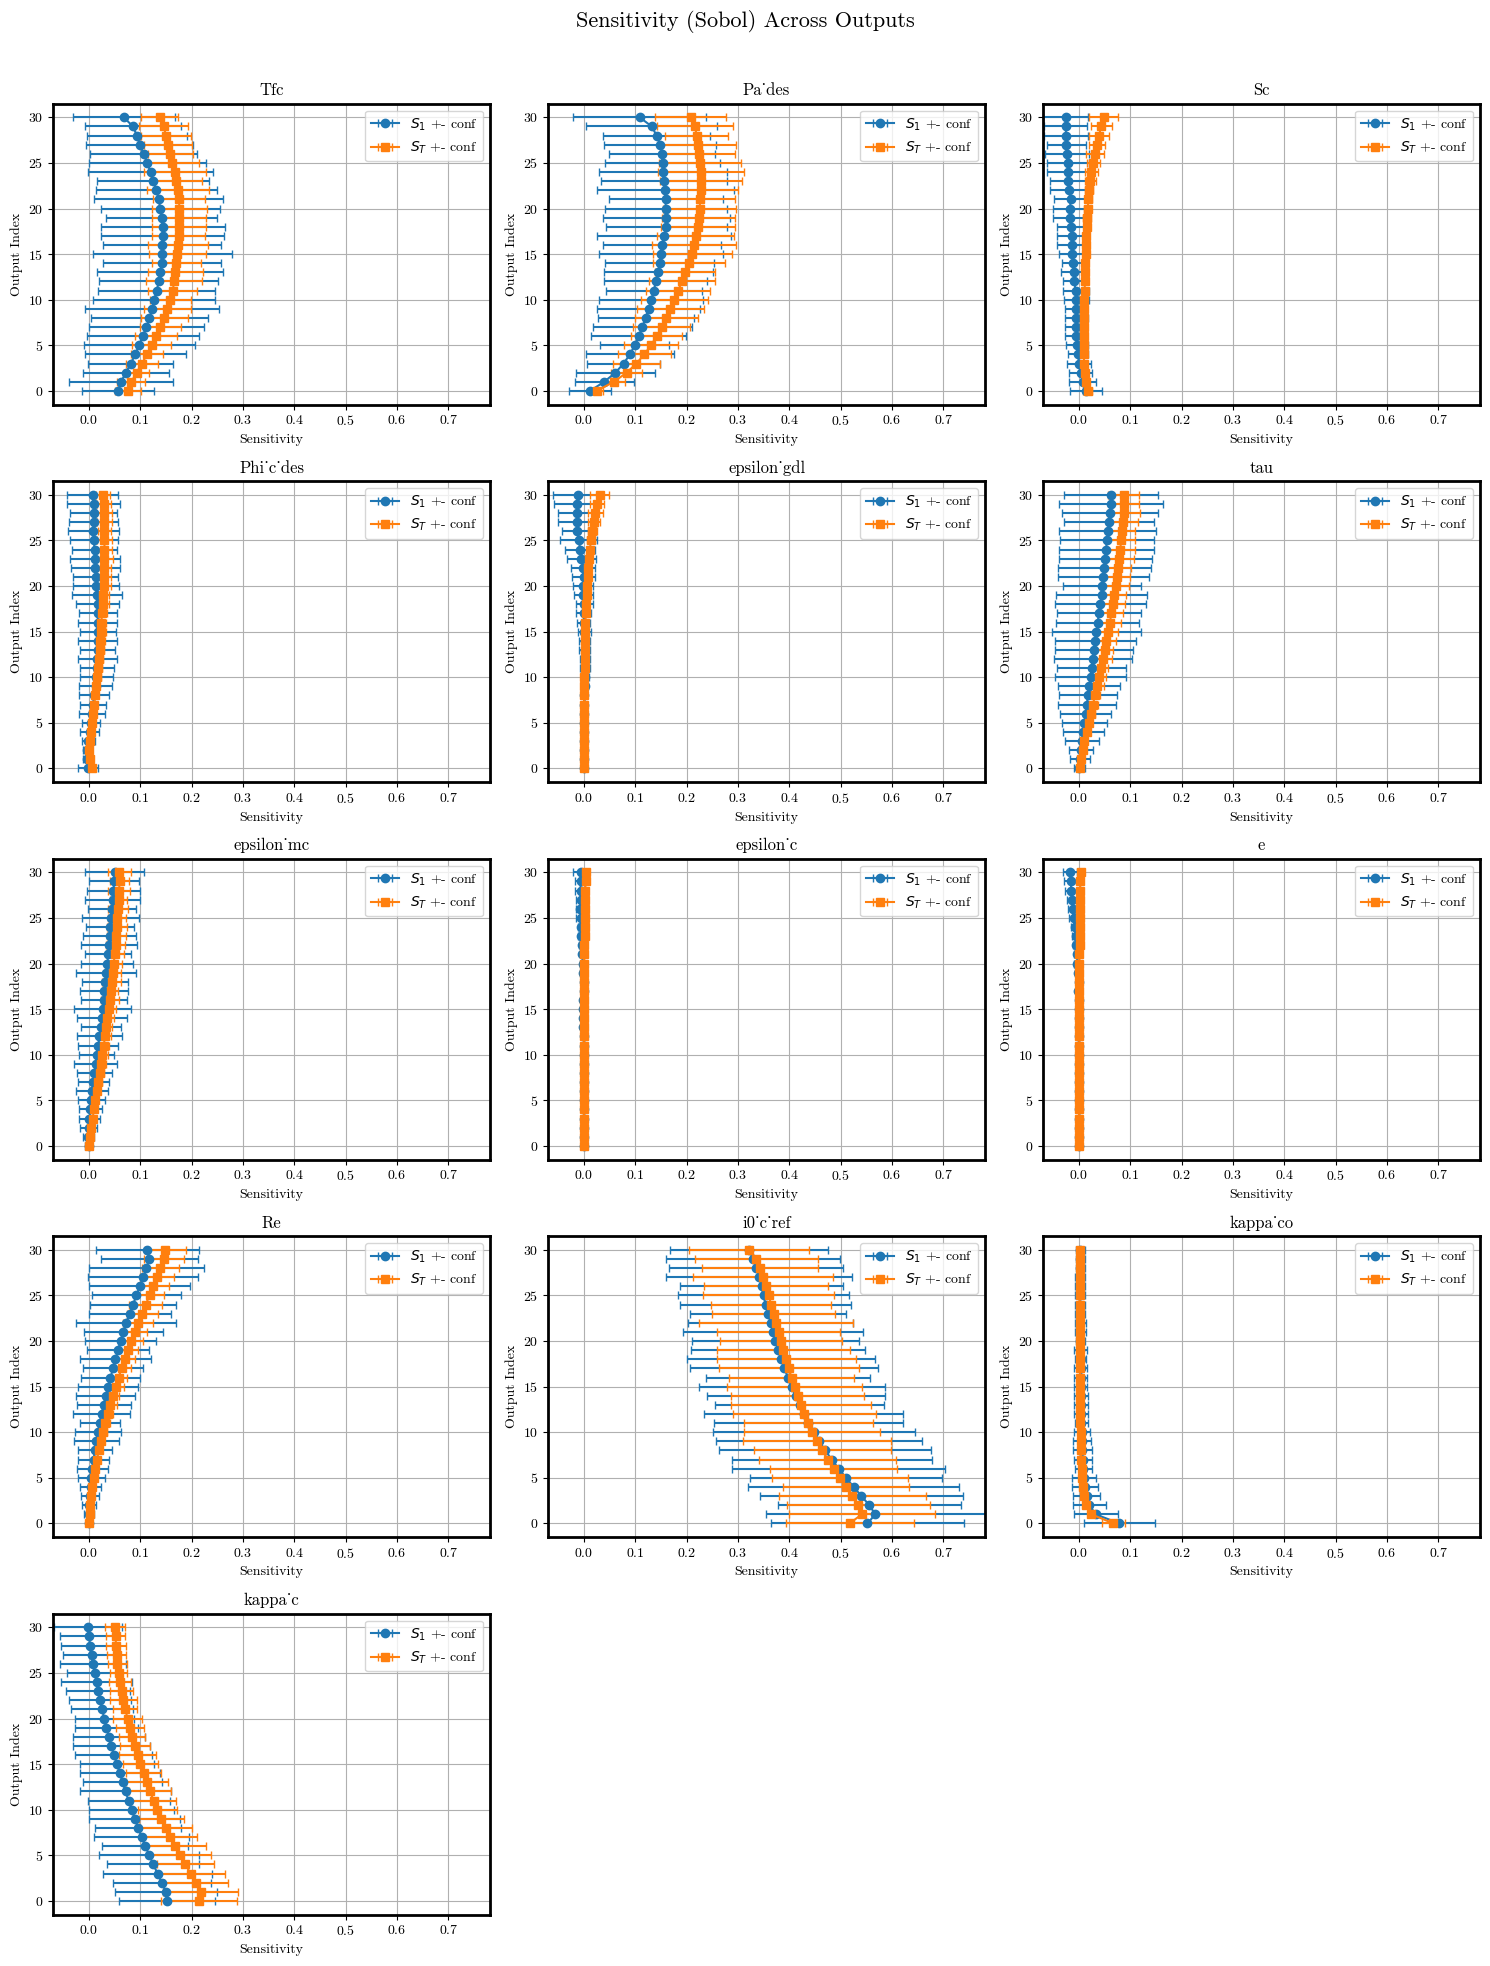

In [17]:
SA = SensitivityAnalyzer(parameter_ranges, dependent_parameter_names=None, method='sobol', seed=42, N=128 , calculate_second_order=True)
samples = SA.generate_samples()
cols = list(samples.columns)
cols.append('Ucell')
cols.append('ifc')
results = SA.run_analysis(final_imputed[cols][:len(samples)], by_regions=None, aggregation_method=None)
SA.plot_grid(results)

In [9]:
def format_output(rankings,Ns):
    rows = []
    for i, feature_dict in enumerate(rankings):
        for feature, values in feature_dict.items():
            row = {
                'id': Ns[i],  # your ID list
                'feature': feature
            }
            # Add region columns dynamically inside the loop
            for region_idx, val in enumerate(values):
                row[f'region_{region_idx}'] = val

            rows.append(row)  # Append inside the inner loop so every feature gets a row

    # Create the DataFrame
    df_rankings = pd.DataFrame(rows)
    return df_rankings


def compute_rankings_for_Ns(parameter_ranges, data, Ns, aggregation_method, by_regions,calculate_second_order=True):
    rankings = []
    indices =[]
    indicess1 =[]
    param_names = None

    for N in Ns:
        SA = SensitivityAnalyzer(
            parameter_ranges,
            dependent_parameter_names=None,
            method='sobol',
            seed=42,
            N=N,
            calculate_second_order=calculate_second_order
        )
        samples = SA.generate_samples()
        subdata = data.iloc[:len(samples)]
        results = SA.run_analysis(subdata, aggregation_method=aggregation_method, by_regions= by_regions)

        # grab ST for output_index 0
        if param_names is None:
            param_names = results[0]['param']

        rank_outputs = []
        indices_outputs =[]
        indices_s1_outputs =[]
        for i in range(len(results)):
            st = next(r['ST'] for r in results if r['output_index'] == i)
            s1 = next(r['S1'] for r in results if r['output_index'] == i)
                        
            order = np.argsort(-st)     # descending
            ranks = np.empty_like(order)
            ranks[order] = np.arange(1, len(st)+1)
            rank_outputs.append(ranks)
            indices_outputs.append(st)
            indices_s1_outputs.append(s1)

        rankings.append(dict(zip(param_names, np.stack(rank_outputs).T)))
        indices.append(dict(zip(param_names, np.stack(indices_outputs).T)))
        indicess1.append(dict(zip(param_names, np.stack(indices_s1_outputs).T)))
    
    df_rankings =  format_output(rankings,Ns)
    df_indices =  format_output(indices,Ns)
    df_indicess1 =  format_output(indicess1,Ns)

 
    return df_rankings,df_indices,df_indicess1


In [10]:
# 1) build the full N list
Ns = list(range(2, 2048, 4))   # [2, 6, 10, …, 254]
subdata =final_imputed[list(parameter_ranges.keys())+['ifc','Ucell']]#.iloc[:len(samples)]
# 2) compute rank_df however you have it
rank_df,indices_df,indices_s1 = compute_rankings_for_Ns(parameter_ranges, subdata, Ns, aggregation_method="AUC",by_regions=True)

d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))
d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\scipy\stats\_qmc.py:993: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)
d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or

In [11]:
indices_s1

,id,feature,region_0,region_1,region_2
0,2,Tfc,0.428216,0.310495,0.128400
1,2,Pa_des,1.231723,0.575719,0.026766
2,2,Sc,-0.568633,0.329984,0.671287
3,2,Phi_c_des,-0.234464,-0.121152,0.344335
4,2,epsilon_gdl,0.000292,0.025252,0.053820
...,...,...,...,...,...
6651,2046,e,0.017615,0.020505,0.011043
6652,2046,Re,-0.012672,-0.010243,-0.004017
6653,2046,i0_c_ref,0.010149,0.009189,-0.002874
6654,2046,kappa_co,0.002502,0.003962,0.000271


In [14]:
import matplotlib.pyplot as plt
# Example Ns list (sample sizes)
def plot_rankings(rank_df,Ns):
    Ns = sorted(rank_df['id'].unique())

    regions = [col for col in rank_df.columns if col.startswith('region_')]

    for region in regions:
        plt.figure(figsize=(10, 6))
        cmap = plt.get_cmap('tab20', len(rank_df['feature'].unique()))

        for idx, feature in enumerate(rank_df['feature'].unique()):
            # Filter rows for the current feature
            feature_data = rank_df[rank_df['feature'] == feature]
            # Sort by sample size id to get consistent order
            feature_data = feature_data.set_index('id').loc[Ns]

            # Get ranking values for current region
            y = feature_data[region]

            plt.plot(Ns, y, color=cmap(idx), label=feature)

        plt.gca().invert_yaxis()
        plt.xticks([2, 32, 64, 96, 128, 256, 512,1024,2048])
        plt.xlabel("Sample size N")
        plt.ylabel("Rank (1 = most important)")
        plt.title(f"Sobol Total-Order Ranking vs. N for {region}")# (Distinct Colors)
        plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize="small", ncol=1)
        plt.tight_layout()
        plt.show()


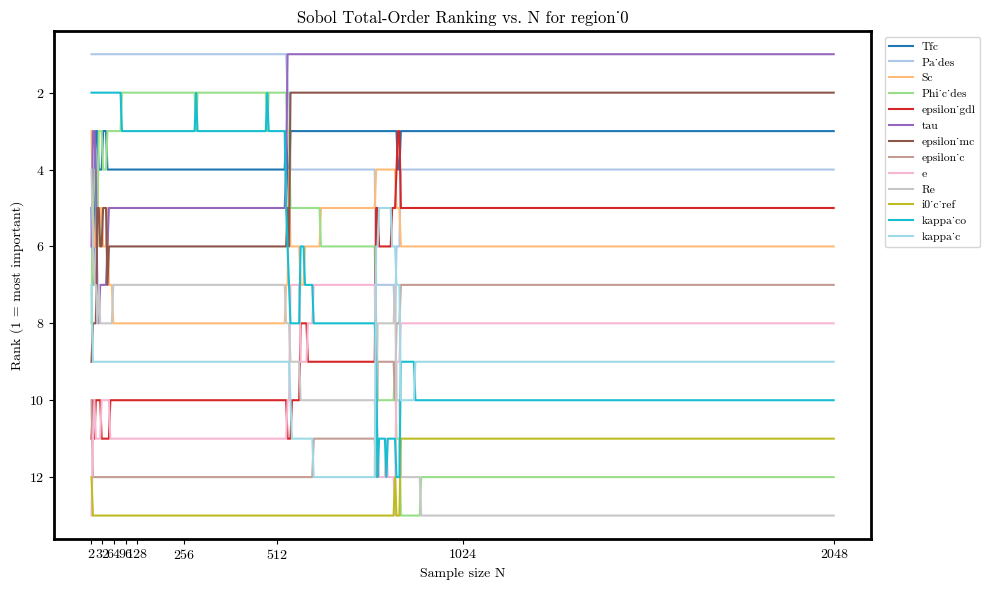

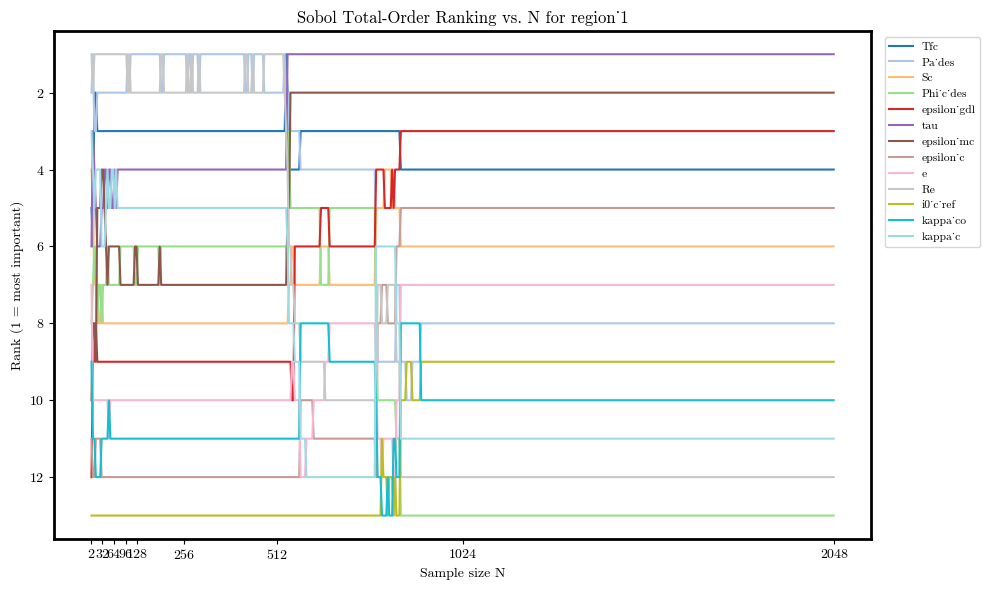

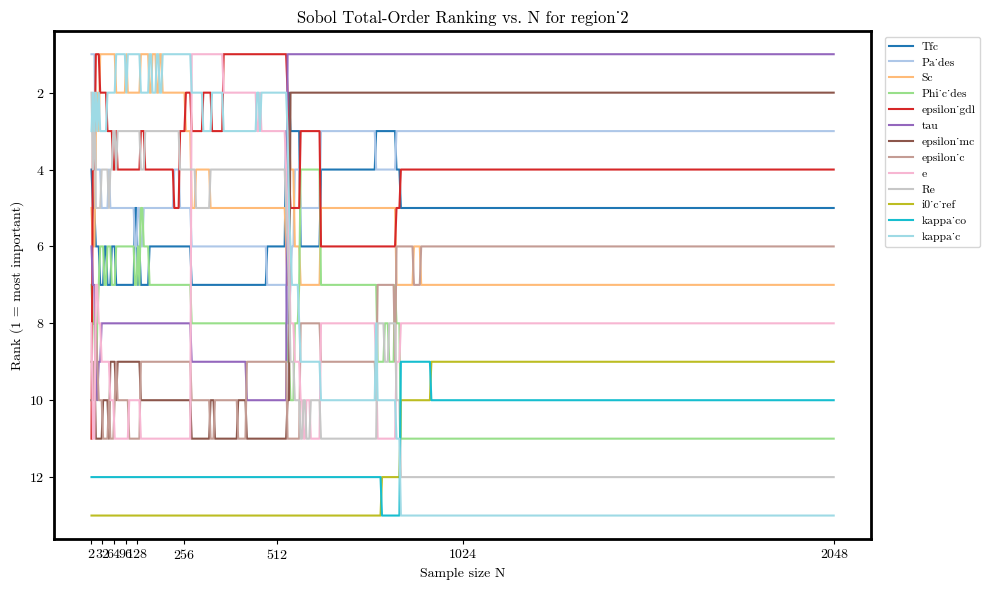

In [15]:
plot_rankings(rank_df,Ns)

d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))
d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\scipy\stats\_qmc.py:993: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)
d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or

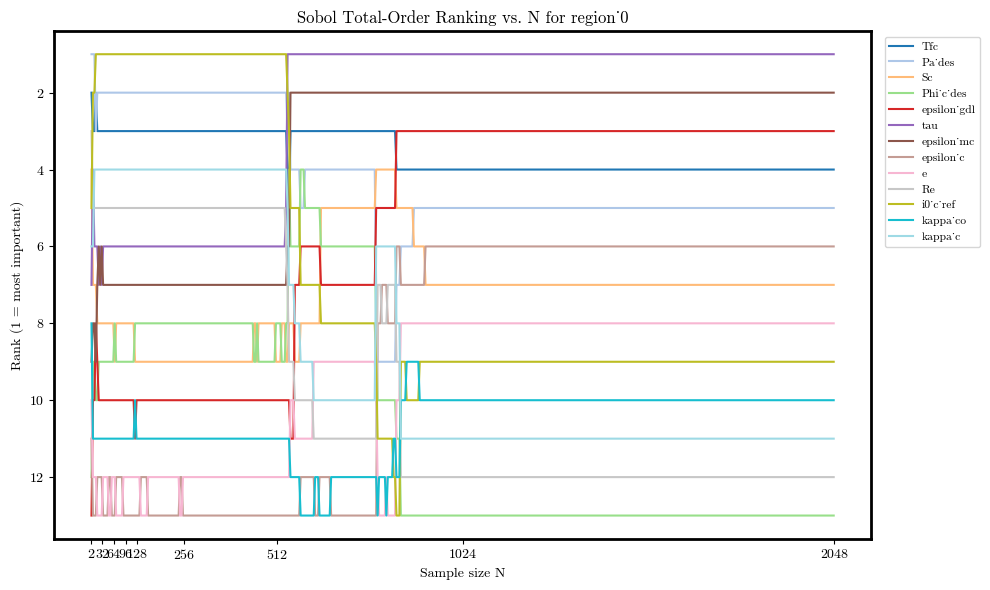

In [16]:
rank_df_1region,indices_df_1region,indices_s1_df_1region = compute_rankings_for_Ns(parameter_ranges, subdata, Ns, aggregation_method="fPCA",by_regions=False)
plot_rankings(rank_df_1region,Ns)

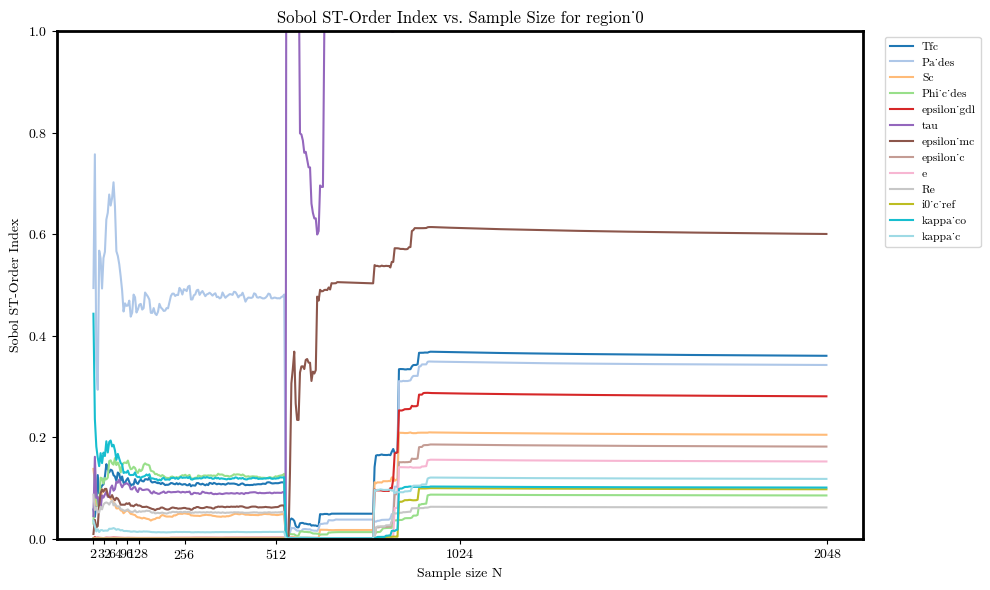

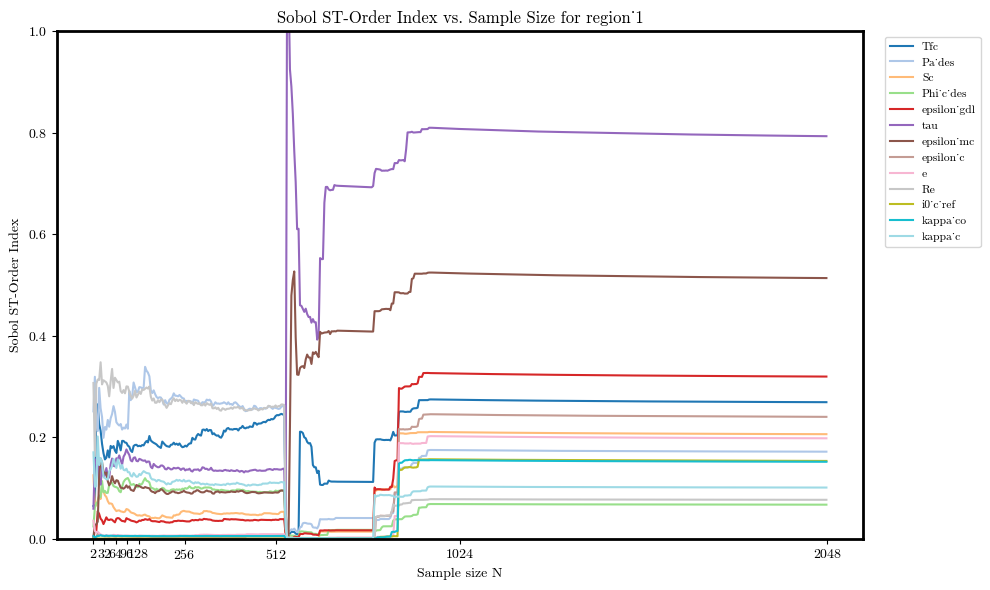

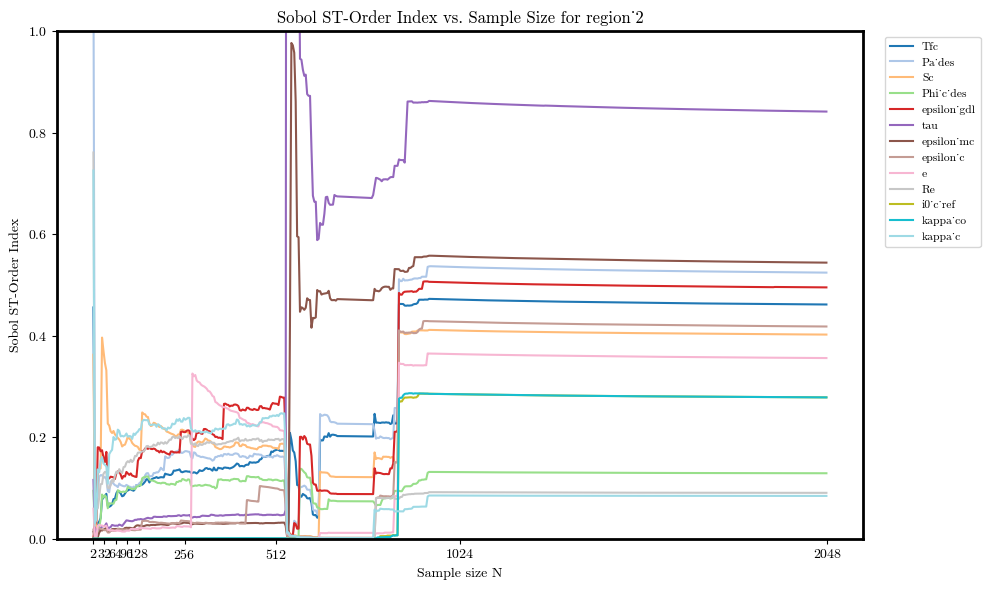

In [17]:
import matplotlib.pyplot as plt

# Assume rank_df has columns: ['id', 'feature', 'region_0', 'region_1', 'region_2', ...]

def plot_indices(indices_df,type="ST"):
    # Get the list of regions from columns
    regions = [col for col in indices_df.columns if col.startswith('region_')]

    # Sort unique sample sizes in 'id'
    Ns = sorted(indices_df['id'].unique())

    for region in regions:
        plt.figure(figsize=(10, 6))
        features = indices_df['feature'].unique()
        cmap = plt.get_cmap('tab20', len(features))

        for idx, feature in enumerate(features):
            # Select rows for this feature and sort by sample size
            df_feature = indices_df[indices_df['feature'] == feature].set_index('id').loc[Ns]

            # y values are Sobol indices/ranks for this feature in the current region
            y = df_feature[region]

            plt.plot(Ns, y, label=feature, color=cmap(idx))

        plt.xlabel("Sample size N")
        plt.ylabel(f"Sobol {type}-Order Index")
        plt.title(f"Sobol {type}-Order Index vs. Sample Size for {region}")
        plt.xticks([2, 32, 64, 96, 128, 256, 512,1024,2048])
        plt.ylim(0, 1)
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize="small")
        plt.tight_layout()
        plt.show()
plot_indices(indices_df= indices_df,type="ST")

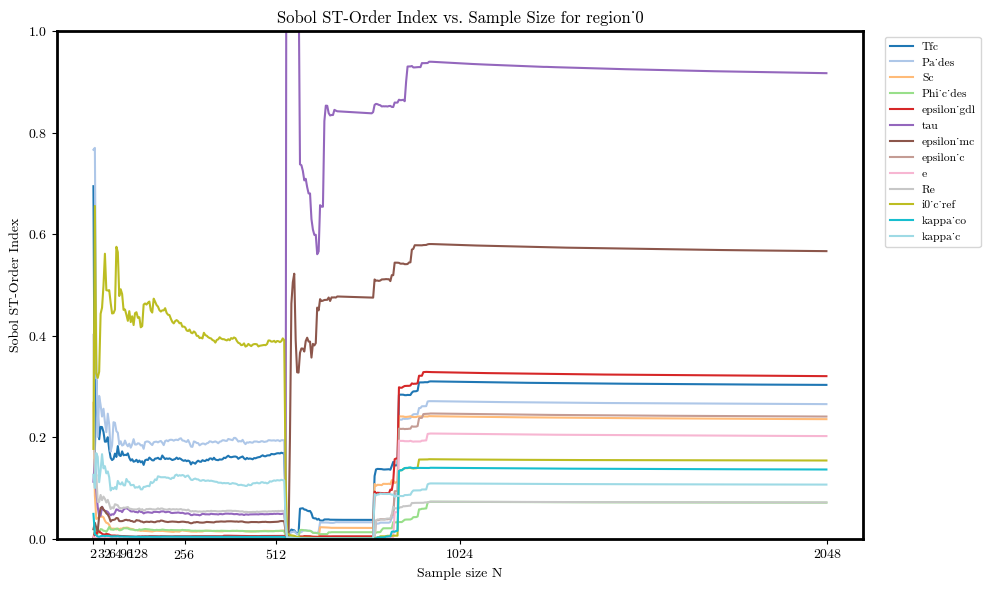

In [19]:
plot_indices(indices_df= indices_df_1region,type="ST")

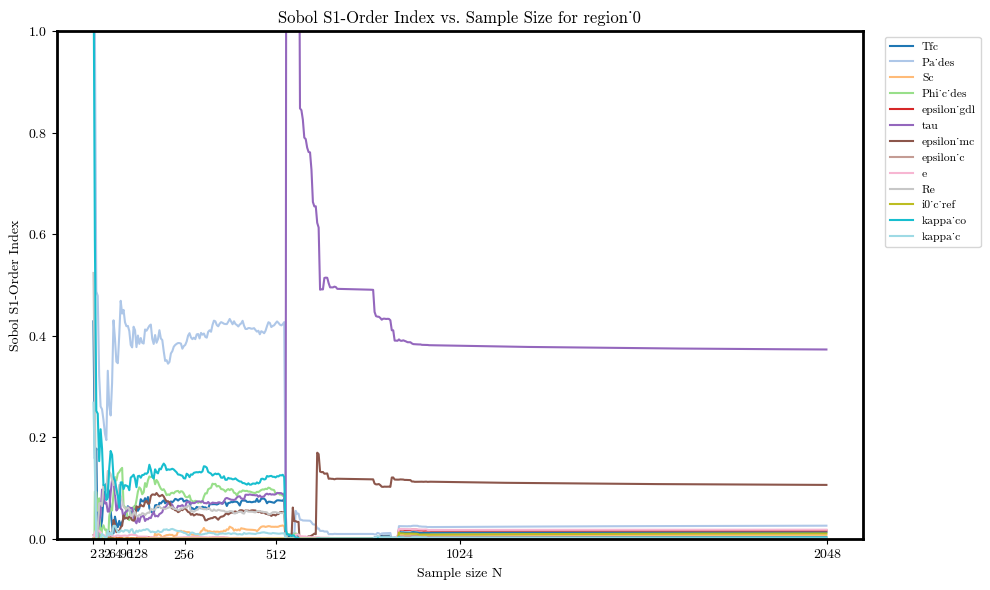

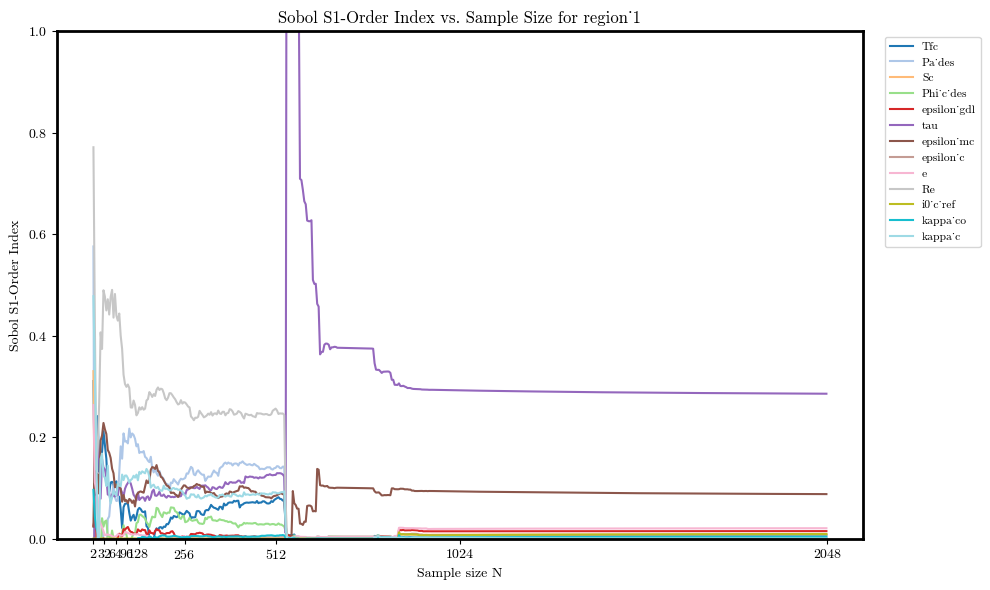

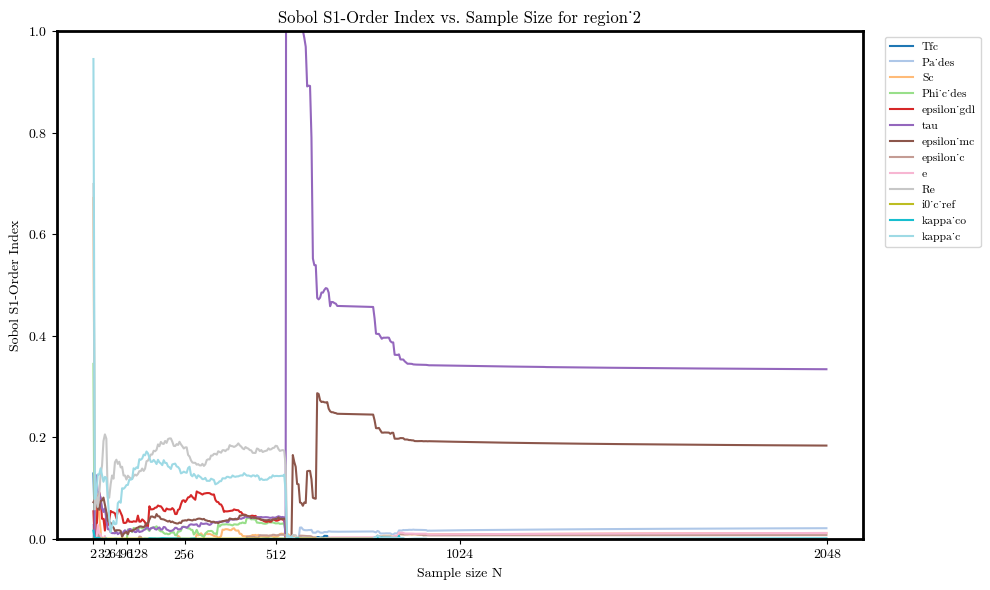

In [36]:
plot_indices(indices_df= indices_s1,type="S1")

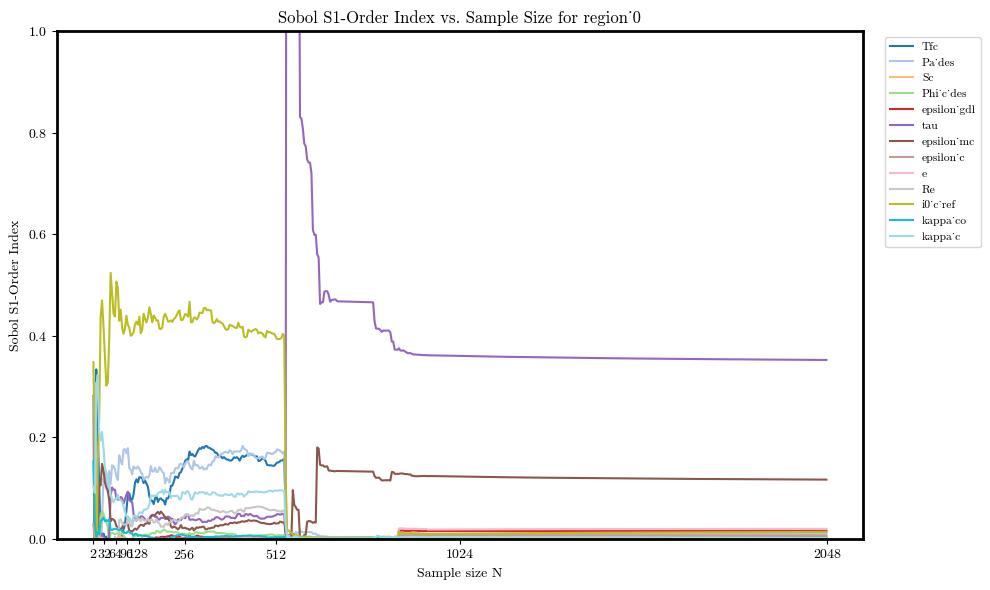

In [20]:
plot_indices(indices_df= indices_s1_df_1region,type="S1")

In [21]:
indices_s1.groupby('id').sum()

,feature,region_0,region_1,region_2
id,,,,
2,TfcPa_desScPhi_c_desepsilon_gdltauepsilon_mcep...,2.494553,2.447372,2.216536
6,TfcPa_desScPhi_c_desepsilon_gdltauepsilon_mcep...,1.686543,0.707478,-0.158344
10,TfcPa_desScPhi_c_desepsilon_gdltauepsilon_mcep...,0.606880,0.494972,-0.138314
14,TfcPa_desScPhi_c_desepsilon_gdltauepsilon_mcep...,0.620488,0.181388,0.139402
18,TfcPa_desScPhi_c_desepsilon_gdltauepsilon_mcep...,0.493377,0.414033,0.091489
...,...,...,...,...
2030,TfcPa_desScPhi_c_desepsilon_gdltauepsilon_mcep...,0.557523,0.426966,0.542088
2034,TfcPa_desScPhi_c_desepsilon_gdltauepsilon_mcep...,0.557523,0.426964,0.542093
2038,TfcPa_desScPhi_c_desepsilon_gdltauepsilon_mcep...,0.557517,0.426941,0.542110


In [22]:
indices_s1[indices_s1['id']==2046]

,id,feature,region_0,region_1,region_2
6643,2046,Tfc,0.012766,-0.002540,-0.003872
6644,2046,Pa_des,0.025482,0.003103,0.020493
6645,2046,Sc,0.006638,0.008026,0.011055
6646,2046,Phi_c_des,-0.002958,-0.000442,-0.009438
6647,2046,epsilon_gdl,0.016009,0.014766,-0.004024
6648,2046,tau,0.372686,0.285527,0.333796
6649,2046,epsilon_mc,0.105826,0.087693,0.183328
6650,2046,epsilon_c,0.003090,0.007273,0.006936
6651,2046,e,0.017615,0.020505,0.011043
6652,2046,Re,-0.012672,-0.010243,-0.004017


In [24]:
SA = SensitivityAnalyzer(
            parameter_ranges,
            dependent_parameter_names=None,
            method='sobol',
            seed=42,
            N=2046,
            calculate_second_order=True
        )
samples = SA.generate_samples()
subdata = final_imputed.iloc[:len(samples)]


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\scipy\stats\_qmc.py:993: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


In [25]:
results = SA.run_analysis(subdata, aggregation_method='AUC', by_regions= True)

d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


In [39]:
second_order= results[2]['S2']

In [75]:
type(second_order)

numpy.ndarray

In [76]:
# Check if A is upper triangular
is_upper = np.allclose(second_order, np.triu(second_order))

# Check if A is lower triangular
is_lower = np.allclose(second_order, np.tril(second_order))

print("Is upper triangular:", is_upper)
print("Is lower triangular:", is_lower)

Is upper triangular: False
Is lower triangular: False


In [43]:
second_order.shape

(13, 13)

In [341]:
type(second_order)

numpy.ndarray

In [41]:
second_order[second_order < 0] = 0

In [48]:
second_order

array([[           nan, 0.00000000e+00, 0.00000000e+00, 1.56274509e-03,
        0.00000000e+00, 0.00000000e+00, 9.89627065e-03, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       [           nan,            nan, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       [           nan,            nan,            nan, 0.00000000e+00,
        0.00000000e+00, 5.93115785e-02, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 6.11383216e-03,
        0.00000000e+00],
       [           nan,            nan,            nan,            nan,
        1.18329351e-03, 0.00000000e+00, 0.00000000e+00, 1.31621966e-02,
        0.00000000e+00, 7.59541418e-03, 1.81297081e-03, 1.45816313e-02,
        0.00000000e+00],
       [           nan,            n

In [ ]:
np.nanmax(second_order)

np.float64(0.1441193304872704)

In [80]:
np.nanmin(second_order)

np.float64(0.0)

In [42]:
np.nansum(second_order)

np.float64(0.5557837727791203)

In [65]:
results[0]['S1']

array([ 1.27682190e-02,  2.54793595e-02,  6.63946449e-03, -2.96175044e-03,
        1.60097115e-02,  3.72682704e-01,  1.05821855e-01,  3.08945833e-03,
        1.76150488e-02, -1.26704027e-02,  1.01506231e-02,  2.50169630e-03,
        3.59312814e-04])

In [43]:
np.sum(results[2]['S1'])

np.float64(0.5421434648802409)

In [44]:
np.sum(results[2]['S1'])+np.triu(second_order, k=1).sum()

np.float64(1.0979272376593612)

In [67]:
np.sum(results[0]['ST'])

np.float64(3.6143487376634202)

In [45]:

results = SA.run_analysis(subdata, aggregation_method='fPCA', by_regions= False)

d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


In [46]:
second_order= results[0]['S2']

In [49]:
np.nansum(second_order)

np.float64(0.6515132214928269)

In [48]:
second_order[second_order < 0] = 0

In [50]:
np.sum(results[0]['S1'])

np.float64(0.5286140277863037)

In [51]:
np.sum(results[0]['S1'])+np.triu(second_order, k=1).sum()

np.float64(1.1801272492791306)